## Tutorial: Measuring Radial Velocities for SB2s with MINATO's `ravel` Module


This hands-on notebook guides you through fitting spectral lines in a double-lined binary (SB2) to extract both radial-velocity curves with `minato.ravel`.

MINATO releases do not include spectra or tutorial datasets. The release version of this notebook will generate a small analytic synthetic time series during execution. The repository fixtures referenced by the current development notebook are not release content.

---

### 1. Prerequisites

Before starting, ensure you have:

- A Python 3.12 or 3.13 environment
- MINATO installed
- Dependencies (see installation notes)
- Synthetic spectra generated in the notebook or your own spectra

---

### JAX / CPU devices on shared servers (important)

When you import `minato.ravel`, it may default to using **all visible CPU cores** (JAX “local devices”). On a shared server this can be the full node, which may be inappropriate.

Set `XLA_FLAGS=--xla_force_host_platform_device_count=<n_cpus>` to a reasonable number **before importing** `ravel`.

- From a terminal (recommended): set the env var before starting Jupyter, e.g. `XLA_FLAGS=--xla_force_host_platform_device_count=16 jupyter lab`.
- From a notebook: restart the kernel, then in the first cell (before importing `ravel`):

```python
import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=16"
from minato import ravel
```

---

### 2. Import Modules and Functions


In [121]:
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
from IPython.display import Image, display
from minato import ravel, myRC

JAX 64-bit enabled: True


<module 'minato.ravel' from '/Users/villasenor/science/github/jvillasr/MINATO/minato/ravel.py'>

---

### 3. Load a Spectrum

Replace `fits_file` and `instrument` with your data path and instrument tag.

In [122]:
data_path = 'synth_spectra/SB2_case1/'
spec_files = sorted(glob(data_path+'*SB2*'))

results_path = 'SB2/'

print(data_path)
spec_files

synth_spectra/


['synth_spectra/synthetic_SB2_01.txt',
 'synth_spectra/synthetic_SB2_02.txt',
 'synth_spectra/synthetic_SB2_03.txt',
 'synth_spectra/synthetic_SB2_04.txt',
 'synth_spectra/synthetic_SB2_05.txt',
 'synth_spectra/synthetic_SB2_06.txt',
 'synth_spectra/synthetic_SB2_07.txt',
 'synth_spectra/synthetic_SB2_08.txt',
 'synth_spectra/synthetic_SB2_09.txt',
 'synth_spectra/synthetic_SB2_10.txt',
 'synth_spectra/synthetic_SB2_11.txt',
 'synth_spectra/synthetic_SB2_12.txt']

As for the SB1 tutorial, we created 12 noise spectra (S/N=30) with R=5000 and vsini=100 km/s, but this time with a shorter orbital period and higher mass ratio, just high enough to identify the system as an SB2

JDs.txt file not found in synth_spectra/.
JDs.txt file not found in synth_spectra/.
JDs.txt file not found in synth_spectra/.
JDs.txt file not found in synth_spectra/.
JDs.txt file not found in synth_spectra/.
JDs.txt file not found in synth_spectra/.
JDs.txt file not found in synth_spectra/.
JDs.txt file not found in synth_spectra/.
JDs.txt file not found in synth_spectra/.
JDs.txt file not found in synth_spectra/.
JDs.txt file not found in synth_spectra/.
JDs.txt file not found in synth_spectra/.


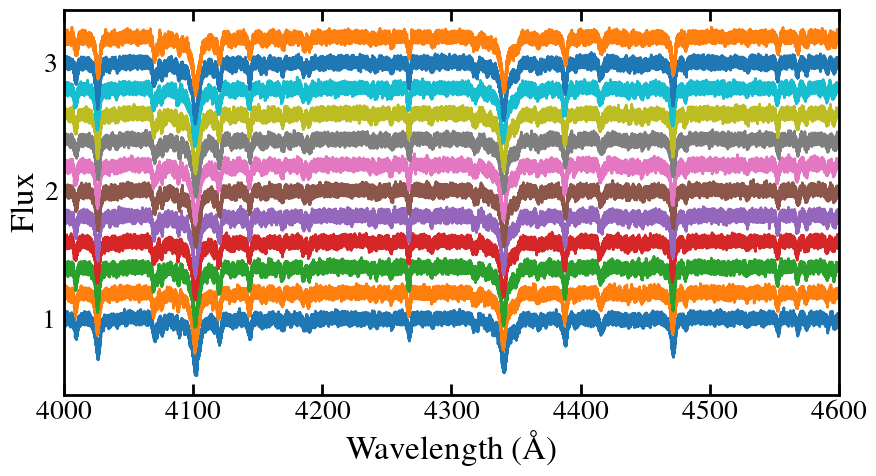

In [109]:
# Read the spectrum
wavelengths, fluxes, f_errors, names, jds = ravel.read_spectra(spec_files, data_path, file_type='txt')

fig, ax = plt.subplots(figsize=(10, 5))
for i, (wave, flux) in enumerate(zip(wavelengths, fluxes)):
    ax.plot(wave, flux + i*0.2, '-', lw=2)
ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux')
ax.set_xlim(4000, 4600)
plt.show()
plt.close()

---

### 4. Setup `ravel.SLfit`

We need to define the spectral lines we want to fit. This time we'll use stronger lines where the contribution of the secondary should be clearer

In [123]:
lines = [4026, 4102, 4340, 4388, 4471]

A quick look to the lines available:

In [111]:
lines_dictionary = ravel.setup_line_dictionary()
lines_dictionary.keys()

dict_keys([3995, 4009, 4026, 4089, 4102, 4121, 4128, 4131, 4144, 4233, 4267, 4340, 4388, 4471, 4481, 4542, 4553, 4861, 4922, 5412, 5876, 5890, 6562, 6678, 7774])

And we run `SLfit` to perform the fit. Note that we have changed the SB2 argument to True. The procedure now is very different to the SB1, and it will directly provide the RVs.

In [124]:
star_path = ravel.SLfit(spec_files, data_path=data_path, save_path=results_path, lines=lines, SB2=True, file_type='txt')



*******************************************************************************
******************           Spectral Line fitting           ******************
*******************************************************************************

*** SB2 set to: True ***


*** Fitting lines ***
---------------------
Lines to be fitted: [4026, 4102, 4340, 4388, 4471]
Fitting all lines simultaneously
Number of lines: 5
Number of epochs: 12

Fitting with Δv_means: [[[-250.]]

 [[ 250.]]]


/Users/villasenor/science/github/jvillasr/MINATO/minato/ravel.py:800: UserWarning: Missing a plate statement for batch dimension -3 at site 'Δv_τk'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng_key, extra_fields=("potential_energy",),
sample: 100%|██████████| 1000/1000 [00:34<00:00, 28.81it/s, 63 steps of size 9.12e-02. acc. prob=0.88] 


Mean log posterior probability: 23984.60704325066
Plotting fits for line: 4026
Setting up spectral-lines fit plots...
  Number of columns: 3
  Number of rows: 4
Plotting fits for line: 4102
Setting up spectral-lines fit plots...
  Number of columns: 3
  Number of rows: 4
Plotting fits for line: 4340
Setting up spectral-lines fit plots...
  Number of columns: 3
  Number of rows: 4
Plotting fits for line: 4388
Setting up spectral-lines fit plots...
  Number of columns: 3
  Number of rows: 4
Plotting fits for line: 4471
Setting up spectral-lines fit plots...
  Number of columns: 3
  Number of rows: 4


You can now see the results of the fit in your `results_path` directory. Here is one of the plots stored by `SLfit`, in this case the He I &lambda;4026 fit.

We purposely created a very difficult case, where the secondary is barely detected, with parameters **M1=12.0 Msun, q=0.65, P=12.0 d and e=0.03**.

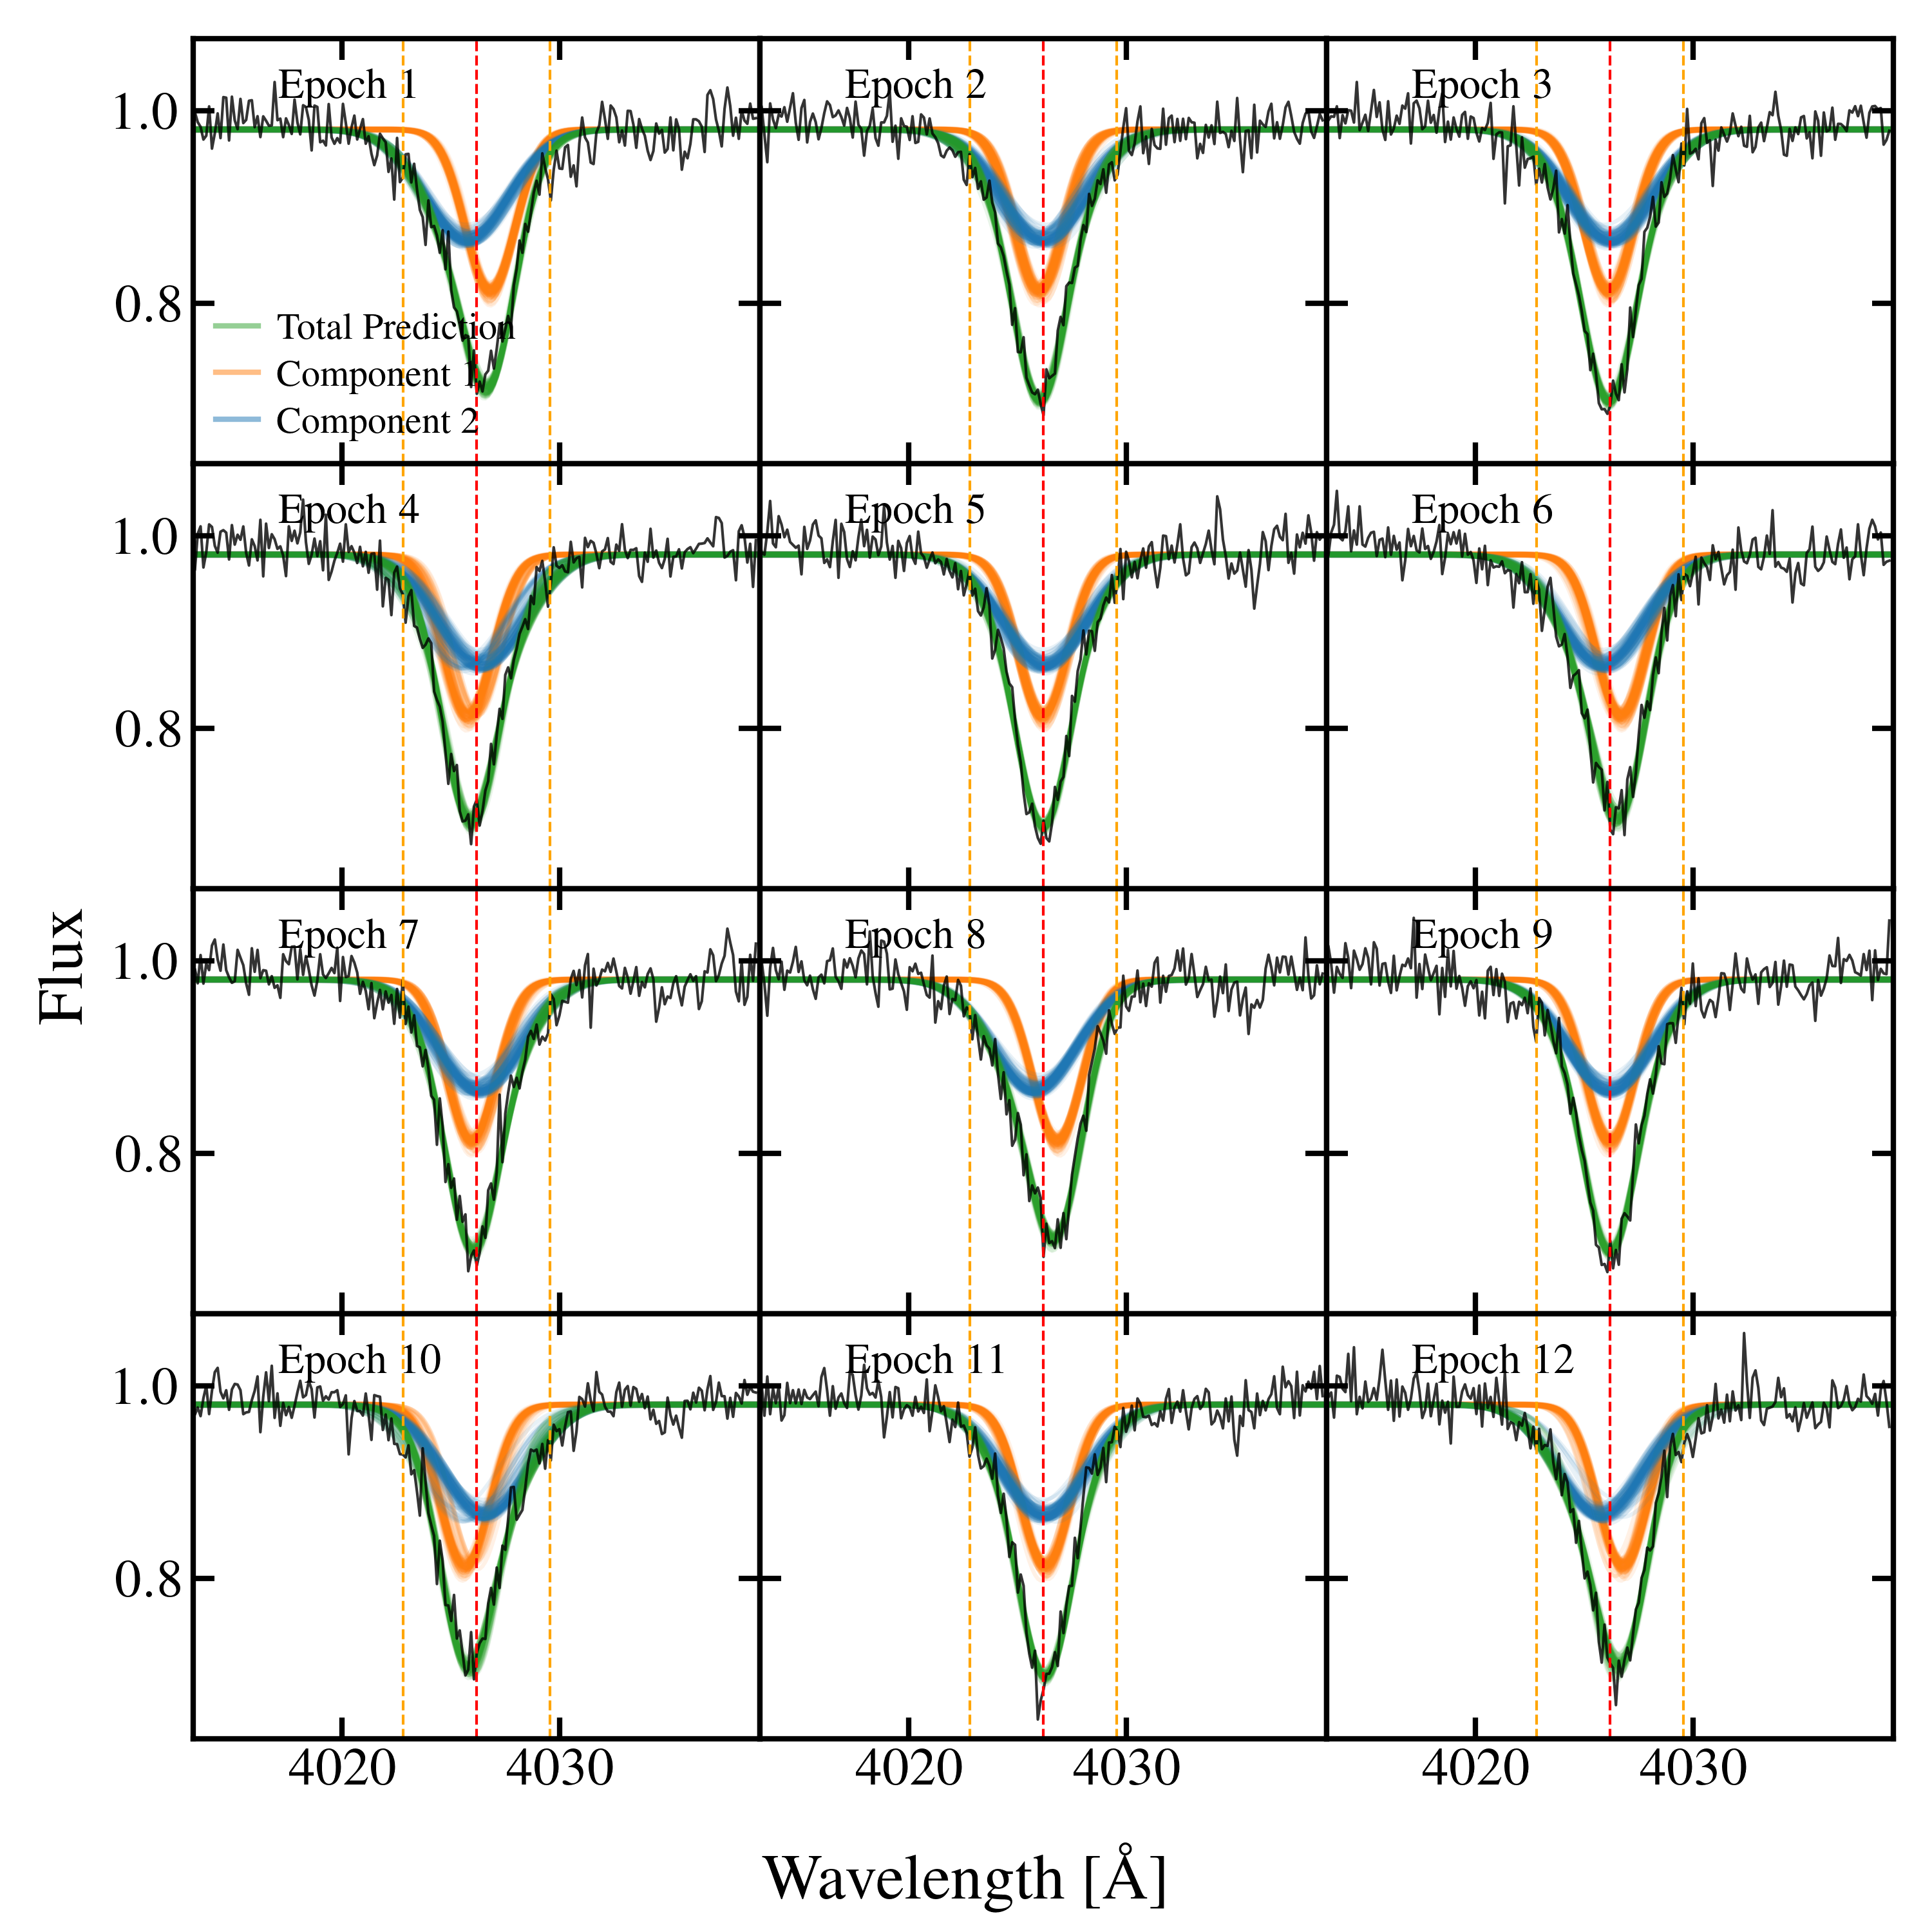

In [125]:
display(Image(
    filename='SB2/SB2/4026_fits_SB2_.png',
    width=600  # pixels
))

---

### 5. Comparing radial velocities

Since we already have the RVs, we can directly compare with the True RVs

Let's first load the results from `ravel.SLfit` containing the RVs for components 1 and 2.

In [126]:
rvs = pd.read_csv(star_path+'fit_values.csv', sep=',')
rvs

,epoch,MJD,mean_rv,mean_rv_er,comp
0,synth_spectra/synthetic_SB2_01,58064.911936,47.292563,5.297145,1
1,synth_spectra/synthetic_SB2_02,58070.039663,-14.630308,8.400902,1
2,synth_spectra/synthetic_SB2_03,58177.066132,-3.245583,7.006173,1
3,synth_spectra/synthetic_SB2_04,58228.926794,-23.644137,12.542193,1
4,synth_spectra/synthetic_SB2_05,58416.992204,-1.121208,5.736148,1
5,synth_spectra/synthetic_SB2_06,58583.029603,37.403054,6.575623,1
6,synth_spectra/synthetic_SB2_07,58637.981640,-15.780583,6.927863,1
7,synth_spectra/synthetic_SB2_08,58666.130396,47.411450,5.194617,1
8,synth_spectra/synthetic_SB2_09,58699.075214,-0.142798,5.431768,1
9,synth_spectra/synthetic_SB2_10,58901.229115,-38.409453,9.532228,1


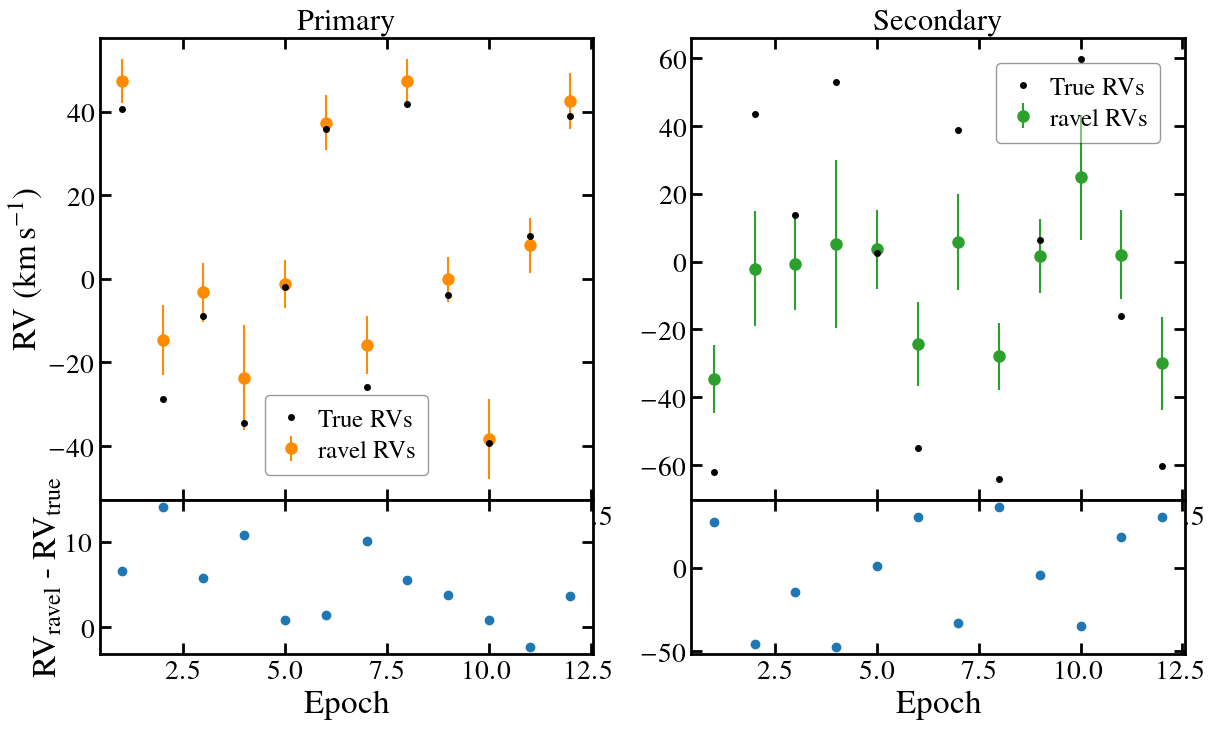

In [127]:
rvs_true_pri = [ 40.71768712, -28.69324071,  -8.96285134, -34.40298556,
         -2.02631691,  35.94965329, -25.82480561,  41.85918986,
         -3.95328884, -39.28187654,  10.37676045,  39.05100681]

rvs_true_sec = [-61.94760552,  43.59487136,  13.66256996,  52.84783445,
          2.61942477, -54.86909013,  38.93766439, -64.16917267,
          6.30976328,  59.74133084, -16.1096475 , -60.29505493]
pri = rvs['comp'] == 1
sec = rvs['comp'] == 2
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(14, 8), gridspec_kw={'hspace': 0., 'height_ratios': [3, 1]})
ax[0,0].errorbar(np.arange(12)+1, rvs['mean_rv'][pri], rvs['mean_rv_er'][pri], fmt='o', ms=8, color='darkorange', label='ravel RVs', zorder=0)
ax[0,0].plot(np.arange(12)+1, rvs_true_pri, '.', ms=8, c='k', label='True RVs', zorder=1)
ax[1,0].plot(np.arange(12)+1, rvs['mean_rv'][pri] - rvs_true_pri, 'o', label='ravel RVs - True RVs')
ax[0,0].set_title('Primary')
ax[0,0].legend()
ax[0,1].errorbar(np.arange(12)+1, rvs['mean_rv'][sec], rvs['mean_rv_er'][sec], fmt='o', ms=8, color='C2', label='ravel RVs', zorder=0)
ax[0,1].plot(np.arange(12)+1, rvs_true_sec, '.', ms=8, c='k', label='True RVs', zorder=1)
ax[1,1].plot(np.arange(12)+1, rvs['mean_rv'][sec] - rvs_true_sec, 'o', label='ravel RVs - True RVs')
ax[0,1].set_title('Secondary')
ax[0,1].legend()
ax[0,0].set(ylabel='RV (km\,s$^{-1}$)')
ax[1,0].set(xlabel='Epoch', ylabel=r'RV$_{\rm ravel}$ - RV$_{\rm true}$')
ax[1,1].set(xlabel='Epoch')
plt.show()
plt.close()

It's clear that the RVs of the primary are mostly within errors, however, for the secondary in most cases the RVs are underestimated.

---

### 6. Orbital period search

Let's see what we find using `ravel`'s wrapper for Astropy's Lomb-Scargle periodogram 

In [128]:
ls_results, phase_results = ravel.lomb_scargle(rvs, star_path, print_output=True, plots=True, SB2=True)

   False alarm levels: ['2.474', '10.357', '36.842']
   FAP of highest peak: 0.00000  (x100:  0.00000 )
   Best frequency                  :  0.083
   ***********************************************
   Best Period                     :  12.00862048 days
   ***********************************************
   Best Period from secondary      :  12.00464785 days
   Period from |RV1-RV2|           :  1.20000008 days correct period = P1 or  6.00431024049301
   Other periods:
     peaks                         :  ['52.176']
     frequencies                   :  ['0.08327']
     periods                       :  ['12.009']
   fal1/P                          :  1.42
   fal2/P                          :  5.04

   Classification index            :  0
   maxpower                        :  52.18
   fal1                            :  36.84
   maxpower_maxfal                 :  1.42
peri_peaks1 size: 1
periods: [12.00862048]

Computing phases for period=12.00862048098602, from 1 periods

Computing phas

/Users/villasenor/science/github/jvillasr/MINATO/minato/ravel.py:2540: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup=3000, num_samples=3000, num_chains=4)
sample: 100%|██████████| 6000/6000 [00:01<00:00, 5625.48it/s, 3 steps of size 4.87e-01. acc. prob=0.93]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        K1     39.57      1.82     39.56     36.55     42.59   9999.63      1.00
   delta_K      1.30      1.22      0.94      0.00      2.94  11656.98      1.00
     gamma      3.97      1.23      3.97      1.90      5.95   9900.63      1.00
      phi0     -0.50      0.04     -0.50     -0.56     -0.43  11699.61      1.00

Number of divergences: 1

*** Plotting phased RV curve ***
-------------------------------


Look at that! Despite the RV differences, we found the correct period from both set of RVs. We can find the periodograms in the `/LS` directory. The periodogram for the primary's RVs looks pretty good:

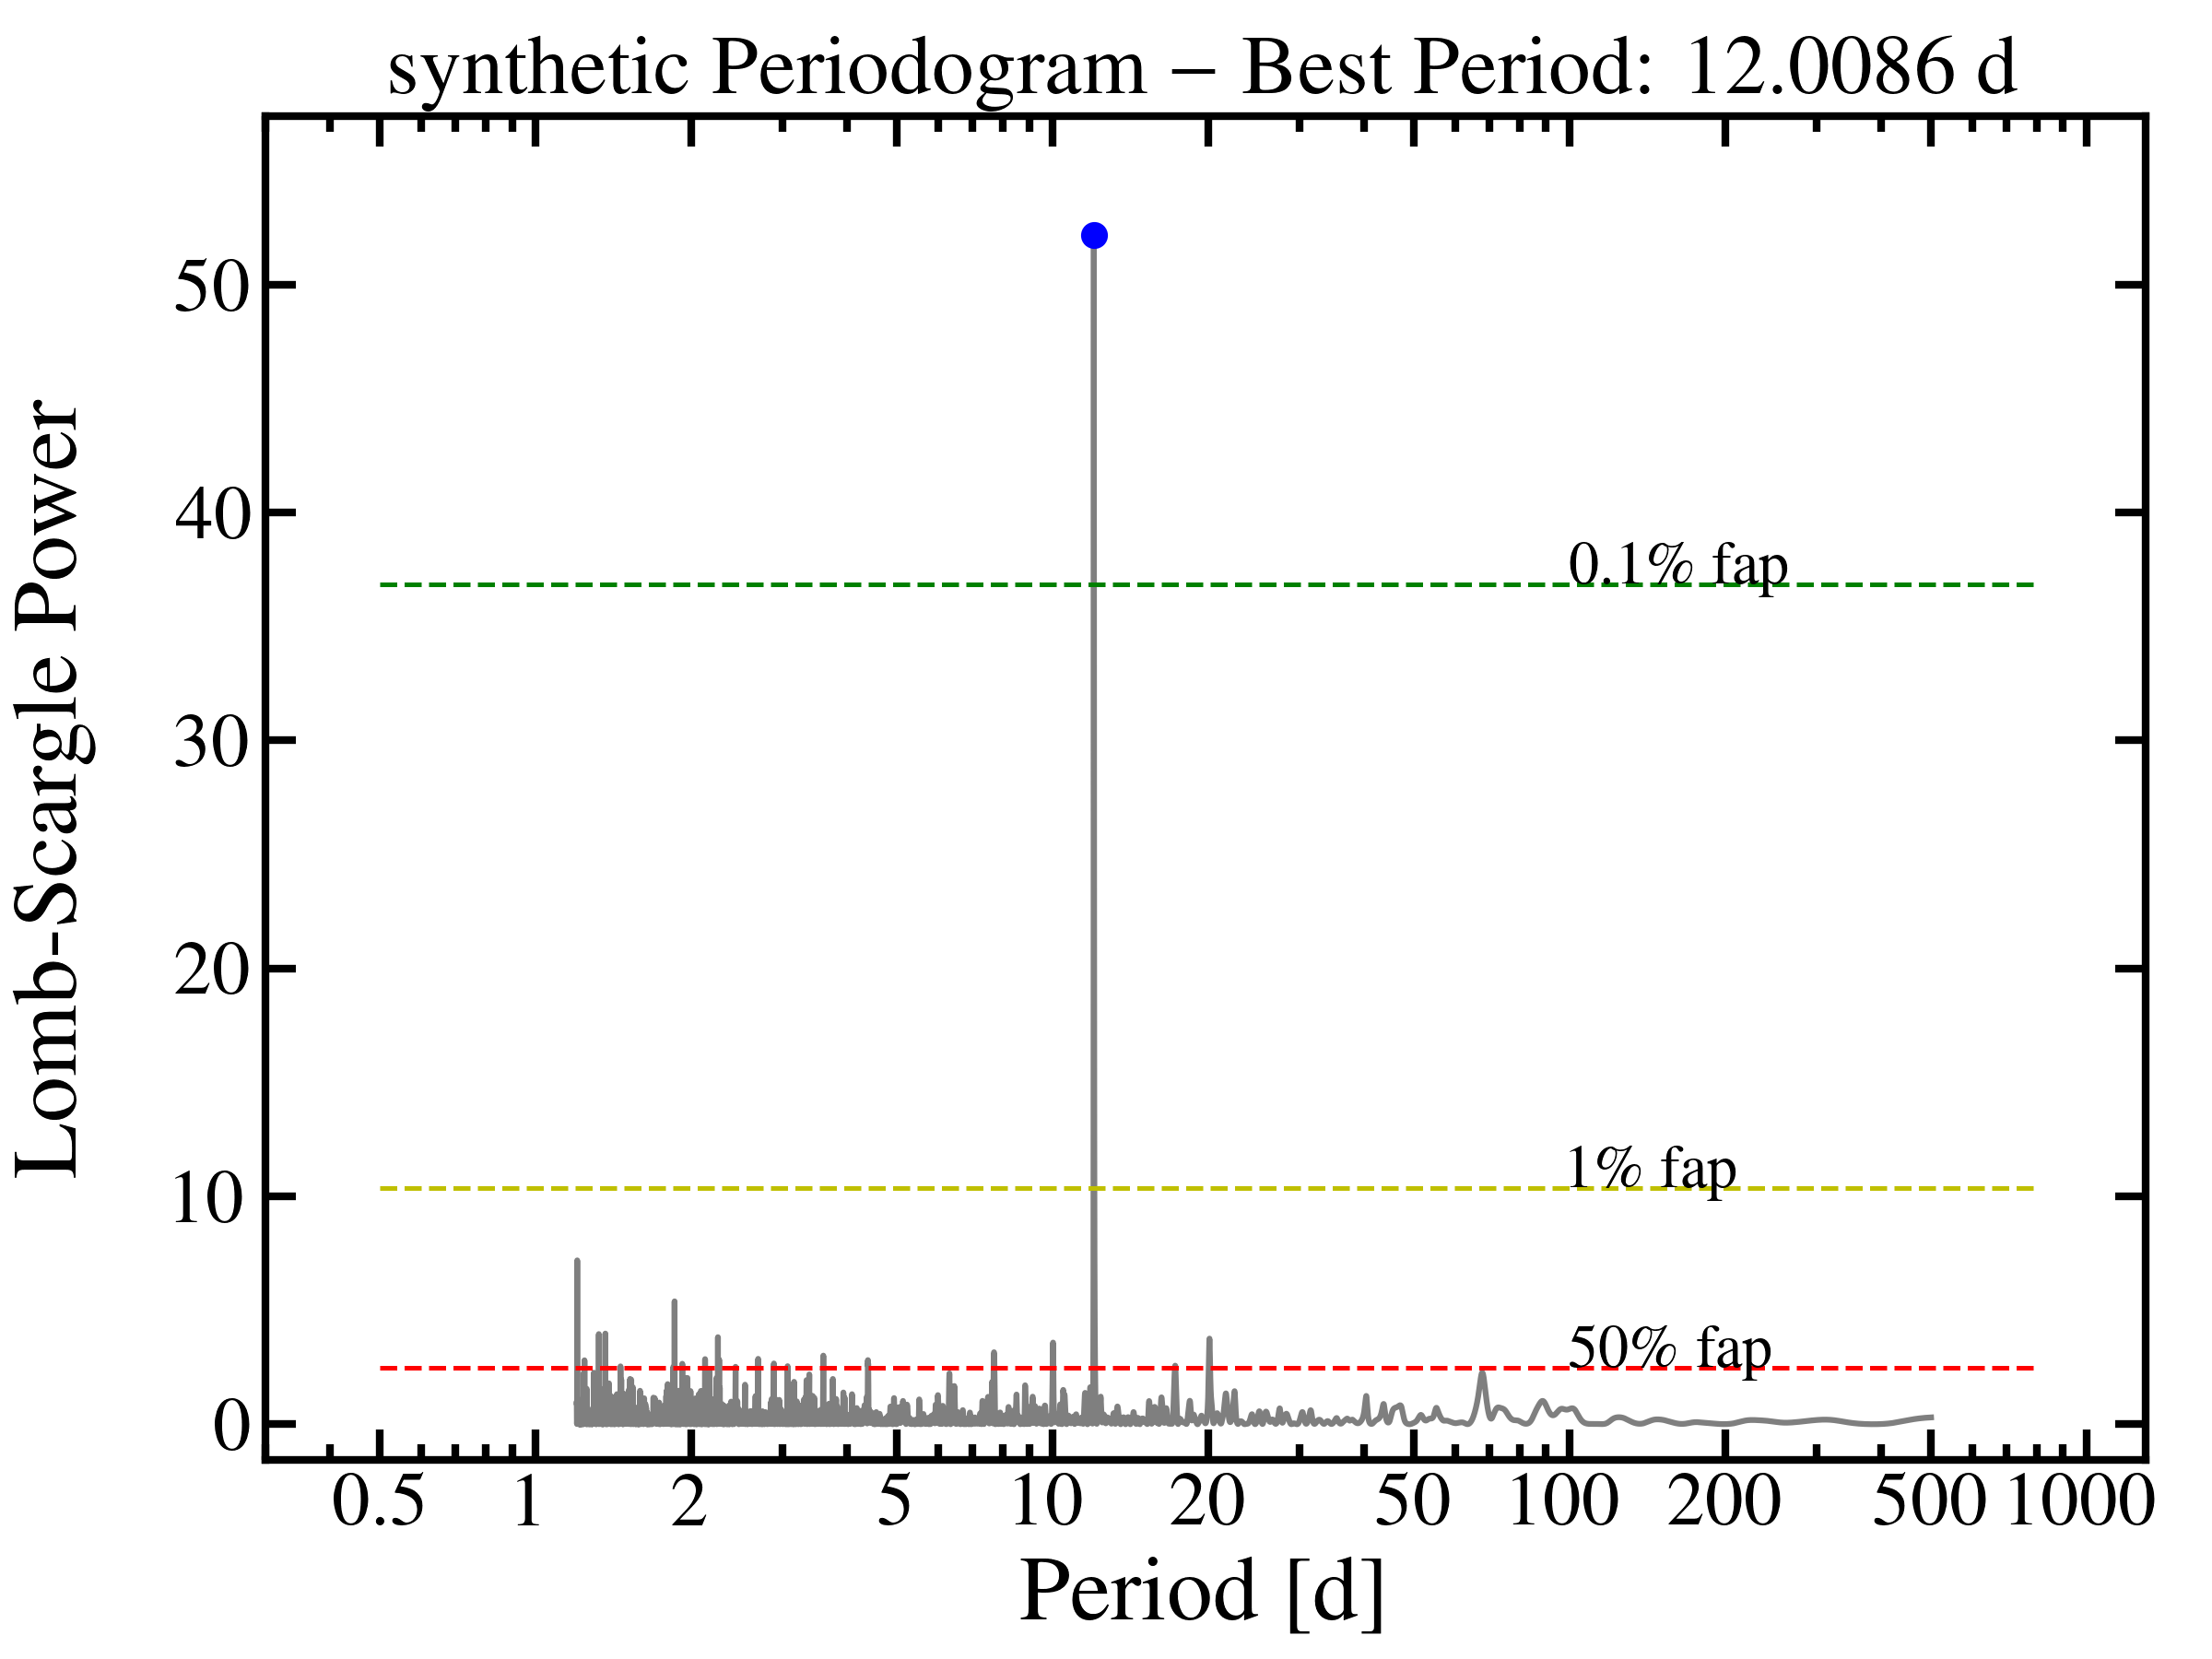

In [129]:
display(Image(
    filename='SB2/SB2/LS/LS_synthetic_period_primary_12_epochs.png',
    width=600  # pixels
))

However, the peak in the periodogram of the secondary didn't reach a 1% false alarm probability:

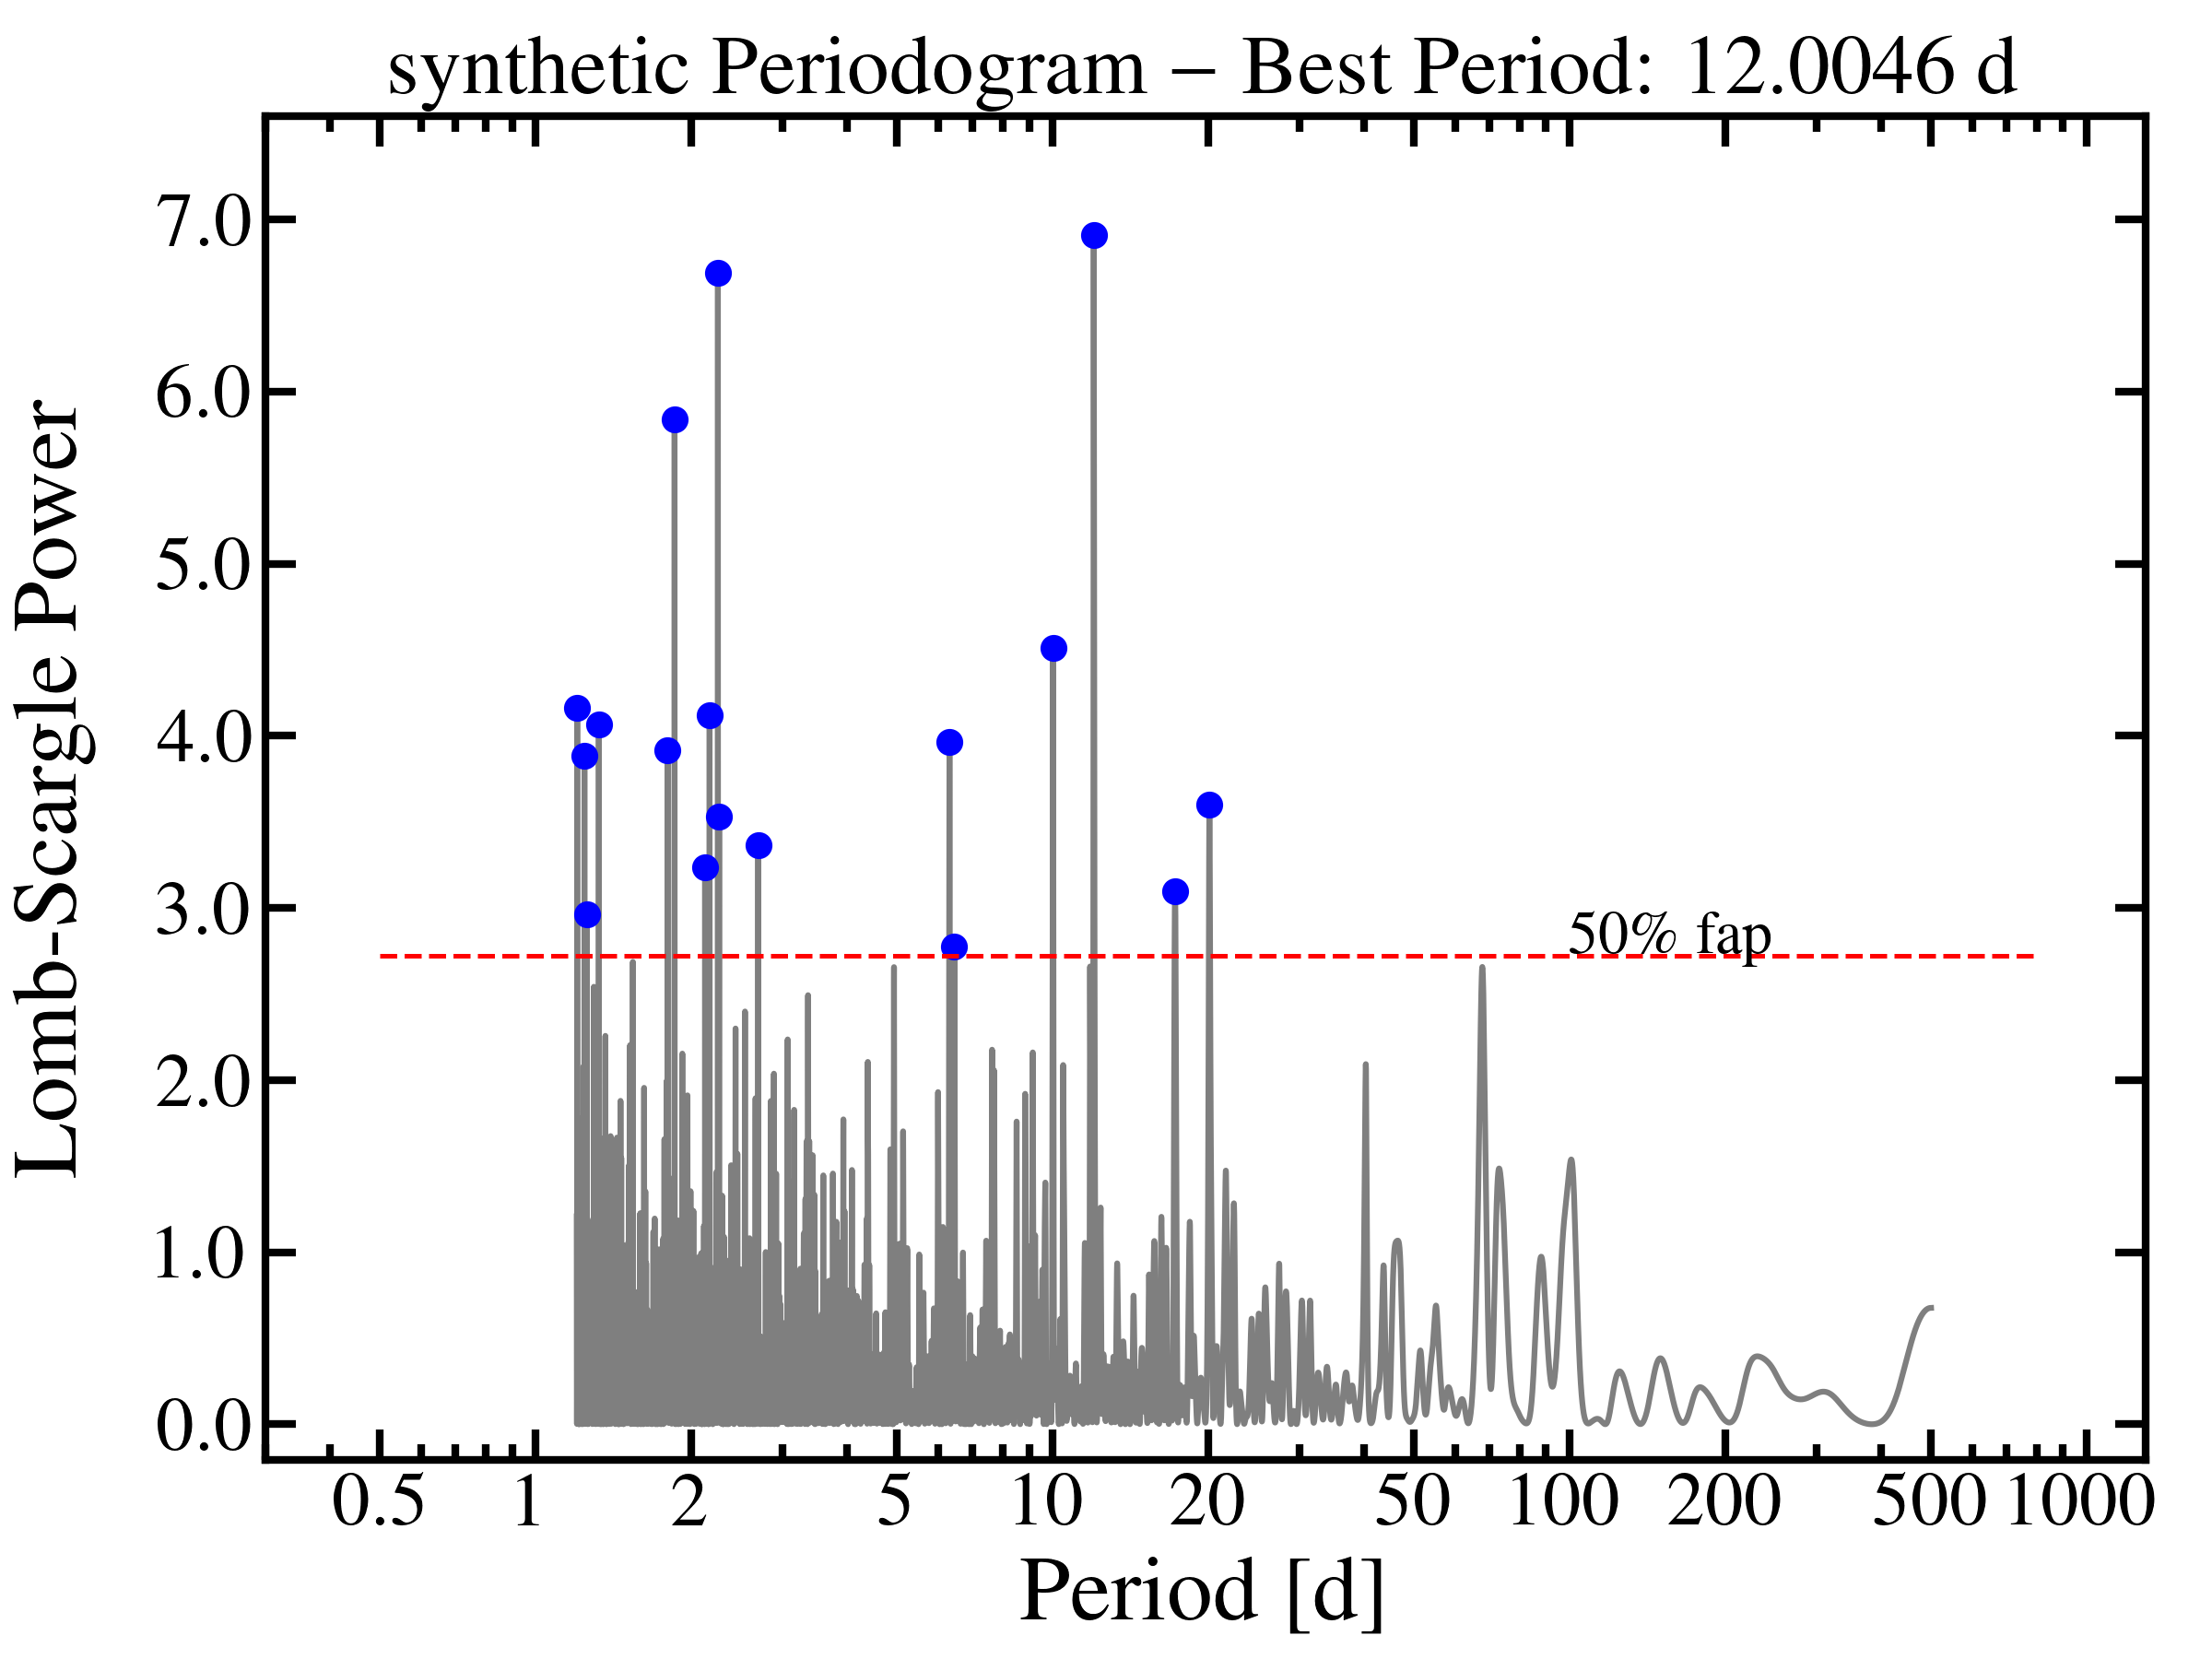

In [130]:
display(Image(
    filename='SB2/SB2/LS/LS_synthetic_period_secondary_12_epochs.png',
    width=600  # pixels
))

We have shown that we can obtain reliable RVs even from highly blended spectra, at least for the dominant star in the spectra!

Finally, let's have a look at the phased RV curve for both components:

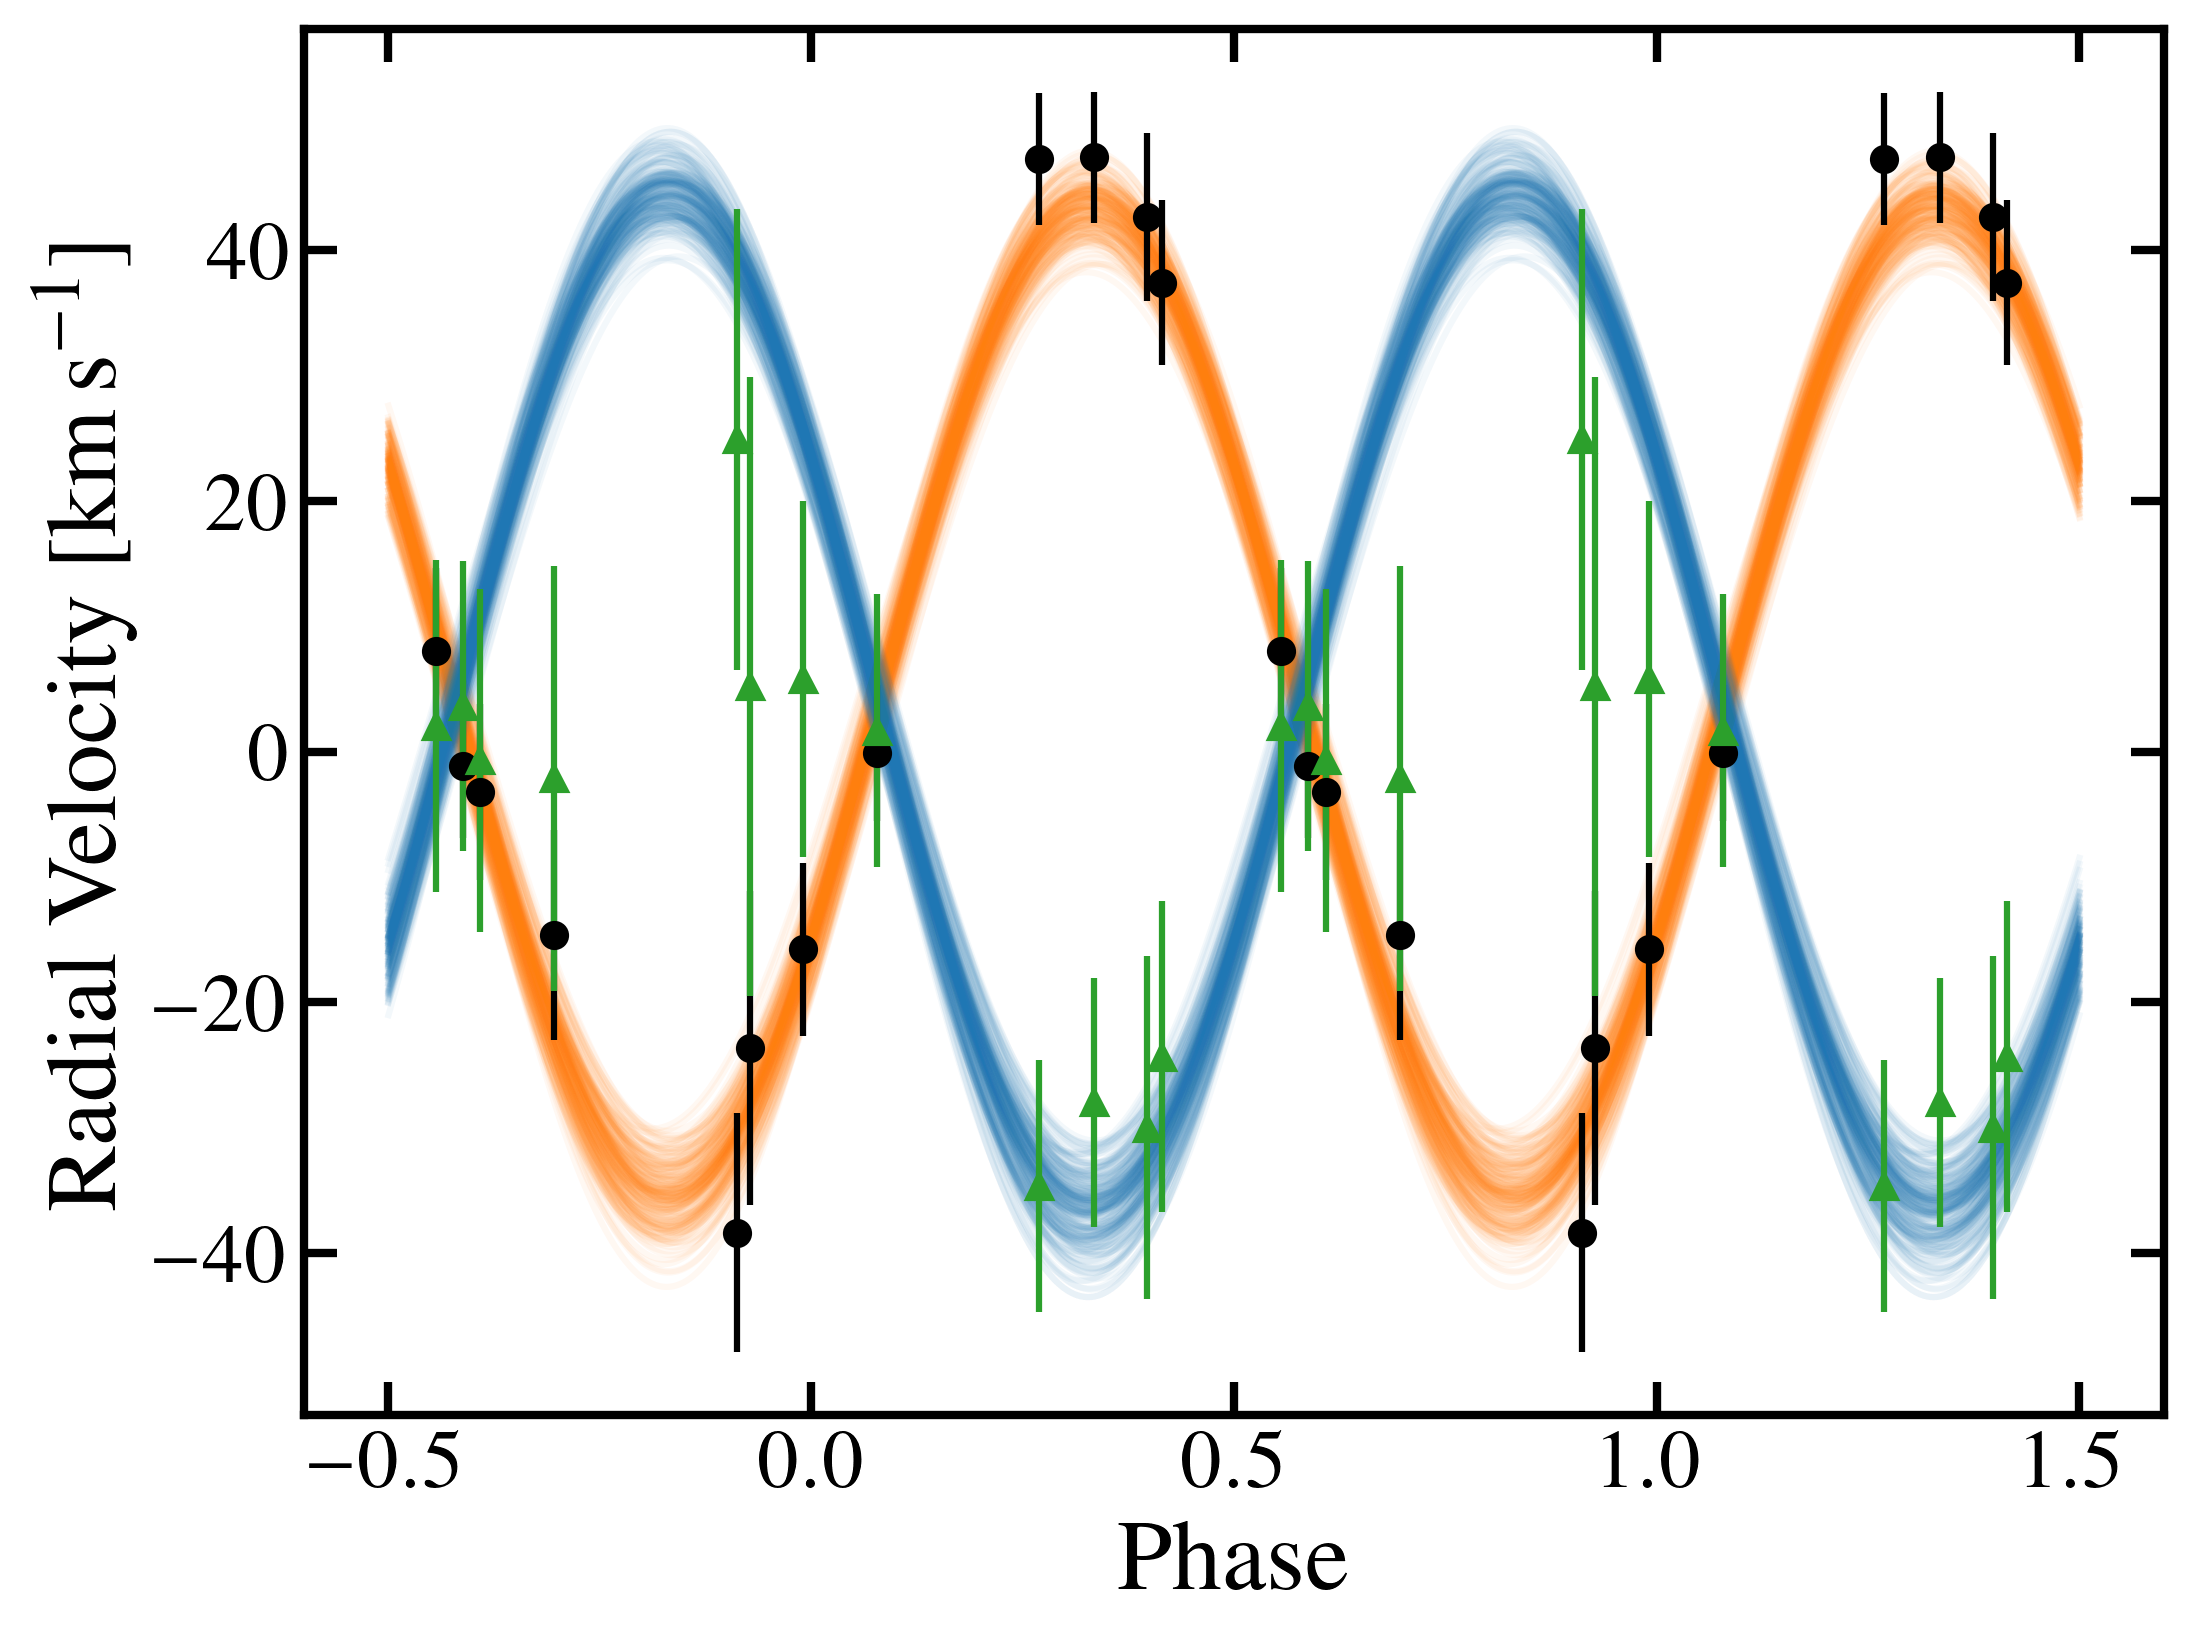

In [131]:
display(Image(
    filename='SB2/SB2/LS/synthetic_sinu_fit_SB2_P=12.01.png',
    width=600  # pixels
))

From `phase_results` we can retrieve K1 and K2 and compute the mass ratio:

In [132]:
K1 = phase_results['K1'].mean()
K2 = phase_results['K2'].mean()
print('K1 (true) =', 41.691995)
print('K1 =', K1, '+/-', phase_results['K1'].std())
q = K1/K2
print('K2 (true) =', 41.691995/0.653925)
print('K2 =', K2, '+/-', phase_results['K2'].std())
print('q (true) =', 0.653925)
print('q =', q)

K1 (true) = 41.691995
K1 = 39.572539051997495 +/- 1.8248907068760443
K2 (true) = 63.75653935848912
K2 = 40.8727327364593 +/- 2.039735972380863
q (true) = 0.653925
q = 0.9681892157090342


As expected, the true K1 is within errors of our measured values, but we have underestimated K2, resulting in a larger mass ratio.

---

## An easier case

Let's see how ravel do with a slightly more evident SB2. We'll use the exact same S/N, R and vsini to create our synthetic spectra, but we'll slightly increase q and decrease P: **M1=12.2, q=0.74	P=10.5, e=0.01**.

We now follow the same steps as before


In [2]:
data_path = 'synth_spectra/SB2_case2/'
spec_files = sorted(glob(data_path+'*SB2*'))

results_path = 'SB2_2/'

print(data_path)
spec_files

synth_spectra/


['synth_spectra/synthetic_case2_SB2_01.txt',
 'synth_spectra/synthetic_case2_SB2_02.txt',
 'synth_spectra/synthetic_case2_SB2_03.txt',
 'synth_spectra/synthetic_case2_SB2_04.txt',
 'synth_spectra/synthetic_case2_SB2_05.txt',
 'synth_spectra/synthetic_case2_SB2_06.txt',
 'synth_spectra/synthetic_case2_SB2_07.txt',
 'synth_spectra/synthetic_case2_SB2_08.txt',
 'synth_spectra/synthetic_case2_SB2_09.txt',
 'synth_spectra/synthetic_case2_SB2_10.txt',
 'synth_spectra/synthetic_case2_SB2_11.txt',
 'synth_spectra/synthetic_case2_SB2_12.txt']

In [7]:
lines = [4026, 4388, 4471]

In [54]:
star_path = ravel.SLfit(spec_files, data_path=data_path, save_path=results_path, lines=lines, SB2=True, file_type='txt')



*******************************************************************************
******************           Spectral Line fitting           ******************
*******************************************************************************

*** SB2 set to: True ***


*** Fitting lines ***
---------------------
Lines to be fitted: [4026, 4388, 4471]
Fitting all lines simultaneously
Number of lines: 3
Number of epochs: 12

Fitting with Δv_means: [[[-250.]]

 [[ 250.]]]


/Users/villasenor/science/github/jvillasr/MINATO/minato/ravel.py:800: UserWarning: Missing a plate statement for batch dimension -3 at site 'Δv_τk'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng_key, extra_fields=("potential_energy",),
sample: 100%|██████████| 1000/1000 [00:12<00:00, 82.04it/s, 15 steps of size 2.06e-01. acc. prob=0.91] 


Mean log posterior probability: 14539.032084044866
Plotting fits for line: 4026
Setting up spectral-lines fit plots...
  Number of columns: 3
  Number of rows: 4
Plotting fits for line: 4388
Setting up spectral-lines fit plots...
  Number of columns: 3
  Number of rows: 4
Plotting fits for line: 4471
Setting up spectral-lines fit plots...
  Number of columns: 3
  Number of rows: 4


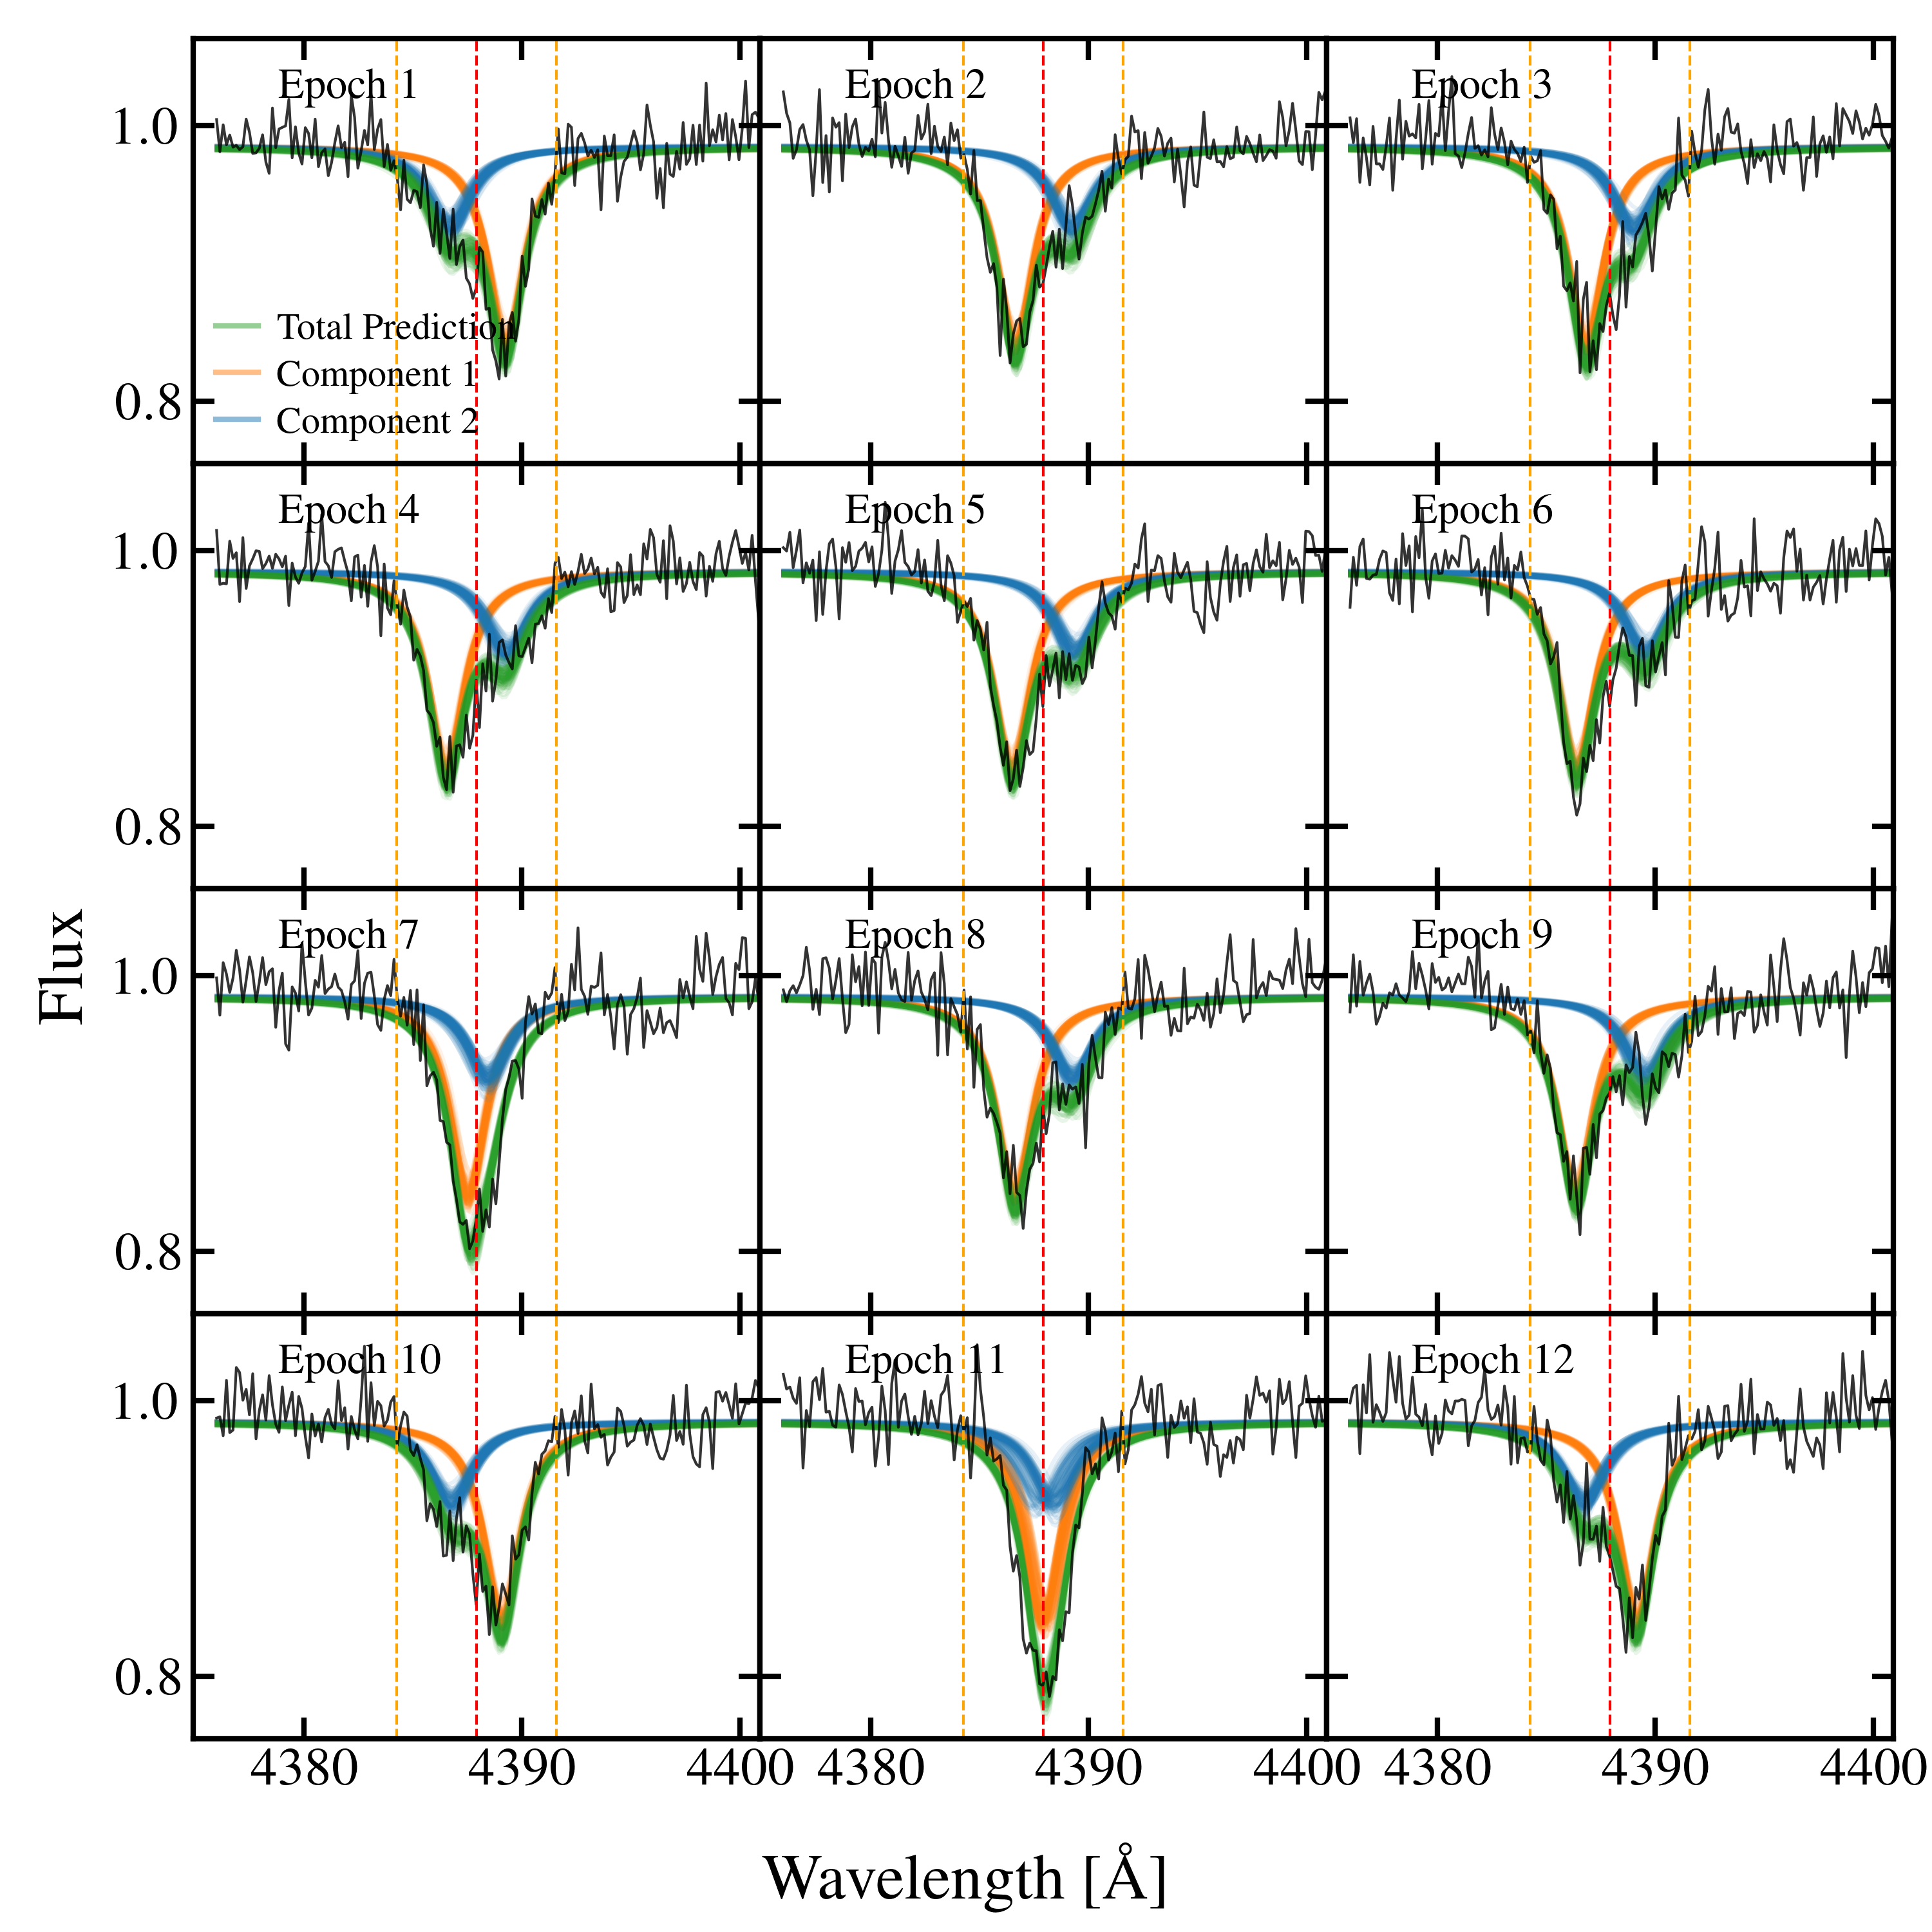

In [15]:
display(Image(
    filename='SB2_2/SB2/4388_fits_SB2_.png',
    width=600  # pixels
))

In [55]:
rvs = pd.read_csv(star_path+'fit_values.csv', sep=',')
rvs

,epoch,MJD,mean_rv,mean_rv_er,comp
0,synth_spectra/synthetic_case2_SB2_01,58064.911936,80.269393,4.781883,1
1,synth_spectra/synthetic_case2_SB2_02,58070.039663,-83.211271,5.606225,1
2,synth_spectra/synthetic_case2_SB2_03,58177.066132,-72.856221,4.770070,1
3,synth_spectra/synthetic_case2_SB2_04,58228.926794,-88.342413,5.216688,1
4,synth_spectra/synthetic_case2_SB2_05,58416.992204,-92.610950,4.837985,1
5,synth_spectra/synthetic_case2_SB2_06,58583.029603,-99.933683,4.923563,1
6,synth_spectra/synthetic_case2_SB2_07,58637.981640,-11.542082,11.271804,1
7,synth_spectra/synthetic_case2_SB2_08,58666.130396,-84.959417,5.429006,1
8,synth_spectra/synthetic_case2_SB2_09,58699.075214,-103.213809,5.143712,1
9,synth_spectra/synthetic_case2_SB2_10,58901.229115,67.140341,5.058695,1


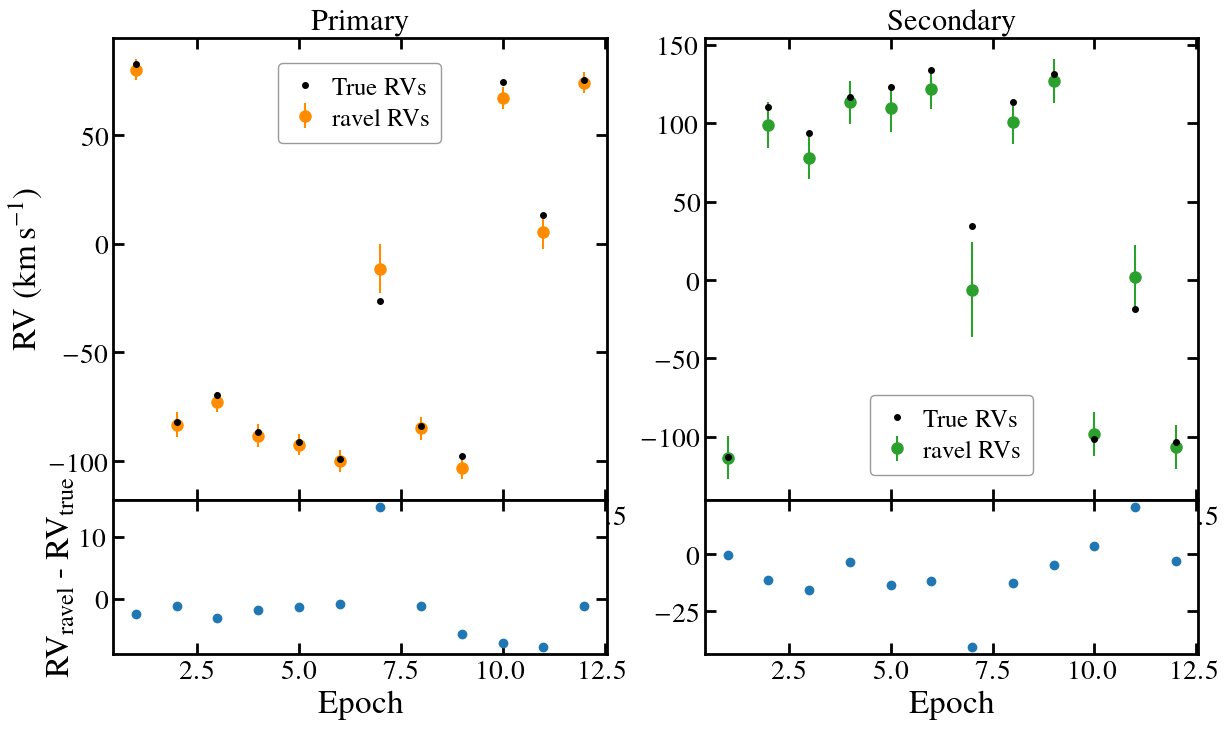

In [56]:
rvs_true_pri = [ 82.76448299, -82.05452627, -69.71351362, -86.48313609,
        -91.27318937, -99.12055103, -26.29279679, -83.8487849 ,
        -97.48034492,  74.30189936,  13.10191676,  75.43347374]

rvs_true_sec = [-112.95898449,  110.1877975 ,   93.6356024 ,  116.53873229,
         123.27646219,  133.77296068,   34.61141278,  113.35778357,
         131.57734988, -101.6643094 ,  -18.52962267, -103.26468563]
pri = rvs['comp'] == 1
sec = rvs['comp'] == 2
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(14, 8), gridspec_kw={'hspace': 0., 'height_ratios': [3, 1]})
ax[0,0].errorbar(np.arange(12)+1, rvs['mean_rv'][pri], rvs['mean_rv_er'][pri], fmt='o', ms=8, color='darkorange', label='ravel RVs', zorder=0)
ax[0,0].plot(np.arange(12)+1, rvs_true_pri, '.', ms=8, c='k', label='True RVs', zorder=1)
ax[1,0].plot(np.arange(12)+1, rvs['mean_rv'][pri] - rvs_true_pri, 'o', label='ravel RVs - True RVs')
ax[0,0].set_title('Primary')
ax[0,0].legend()
ax[0,1].errorbar(np.arange(12)+1, rvs['mean_rv'][sec], rvs['mean_rv_er'][sec], fmt='o', ms=8, color='C2', label='ravel RVs', zorder=0)
ax[0,1].plot(np.arange(12)+1, rvs_true_sec, '.', ms=8, c='k', label='True RVs', zorder=1)
ax[1,1].plot(np.arange(12)+1, rvs['mean_rv'][sec] - rvs_true_sec, 'o', label='ravel RVs - True RVs')
ax[0,1].set_title('Secondary')
ax[0,1].legend()
ax[0,0].set(ylabel='RV (km\,s$^{-1}$)')
ax[1,0].set(xlabel='Epoch', ylabel=r'RV$_{\rm ravel}$ - RV$_{\rm true}$')
ax[1,1].set(xlabel='Epoch')
plt.show()
plt.close()

In [57]:
ls_results, phase_results = ravel.lomb_scargle(rvs, star_path, print_output=True, plots=True, SB2=True)

   False alarm levels: ['2.933', '18.385', '46.719']
   FAP of highest peak: 0.00000  (x100:  0.00000 )
   Best frequency                  :  0.096
   ***********************************************
   Best Period                     :  10.45726017 days
   ***********************************************
   Best Period from secondary      :  10.45835610 days
   Period from |RV1-RV2|           :  5.22779422 days correct period = P1 or  5.2286300825584195
   Other periods:
     peaks                         :  ['559.309', '19.776']
     frequencies                   :  ['0.09563', '0.67422']
     periods                       :  ['10.457', '1.483']
   fal1/P                          :  11.97
   fal2/P                          :  30.42
   fal1/P                          :  0.42
   fal2/P                          :  1.08

   Classification index            :  0
   maxpower                        :  559.31
   fal1                            :  46.72
   maxpower_maxfal                 :  11.9

/Users/villasenor/science/github/jvillasr/MINATO/minato/ravel.py:2540: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup=3000, num_samples=3000, num_chains=4)
sample: 100%|██████████| 6000/6000 [00:01<00:00, 5363.35it/s, 3 steps of size 4.07e-01. acc. prob=0.93] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        K1    108.01      7.24    107.99     98.95    117.16      2.08      4.72
   delta_K     21.47      9.91     22.09      6.80     35.93      2.39      2.35
     gamma      2.83      6.64      2.74     -5.26     11.00      2.06      5.65
      phi0      0.20      2.94      0.23     -2.76      3.14      2.00    234.29

Number of divergences: 0

*** Plotting phased RV curve ***
-------------------------------

Computing phases for period=1.483196456378331, from 2 periods

Computing phases for the secondary star


*** Computing phases ***
------------------------
  period =  1.483196456378331


sample: 100%|██████████| 6000/6000 [00:01<00:00, 5475.86it/s, 3 steps of size 5.80e-01. acc. prob=0.94]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        K1     98.65      1.45     98.64     96.26    100.97  10350.53      1.00
   delta_K     34.64      4.23     34.64     27.45     41.23   9765.40      1.00
     gamma     -9.53      1.09     -9.52    -11.34     -7.75  10279.27      1.00
      phi0     -1.34      0.02     -1.34     -1.37     -1.32  12127.04      1.00

Number of divergences: 0

*** Plotting phased RV curve ***
-------------------------------


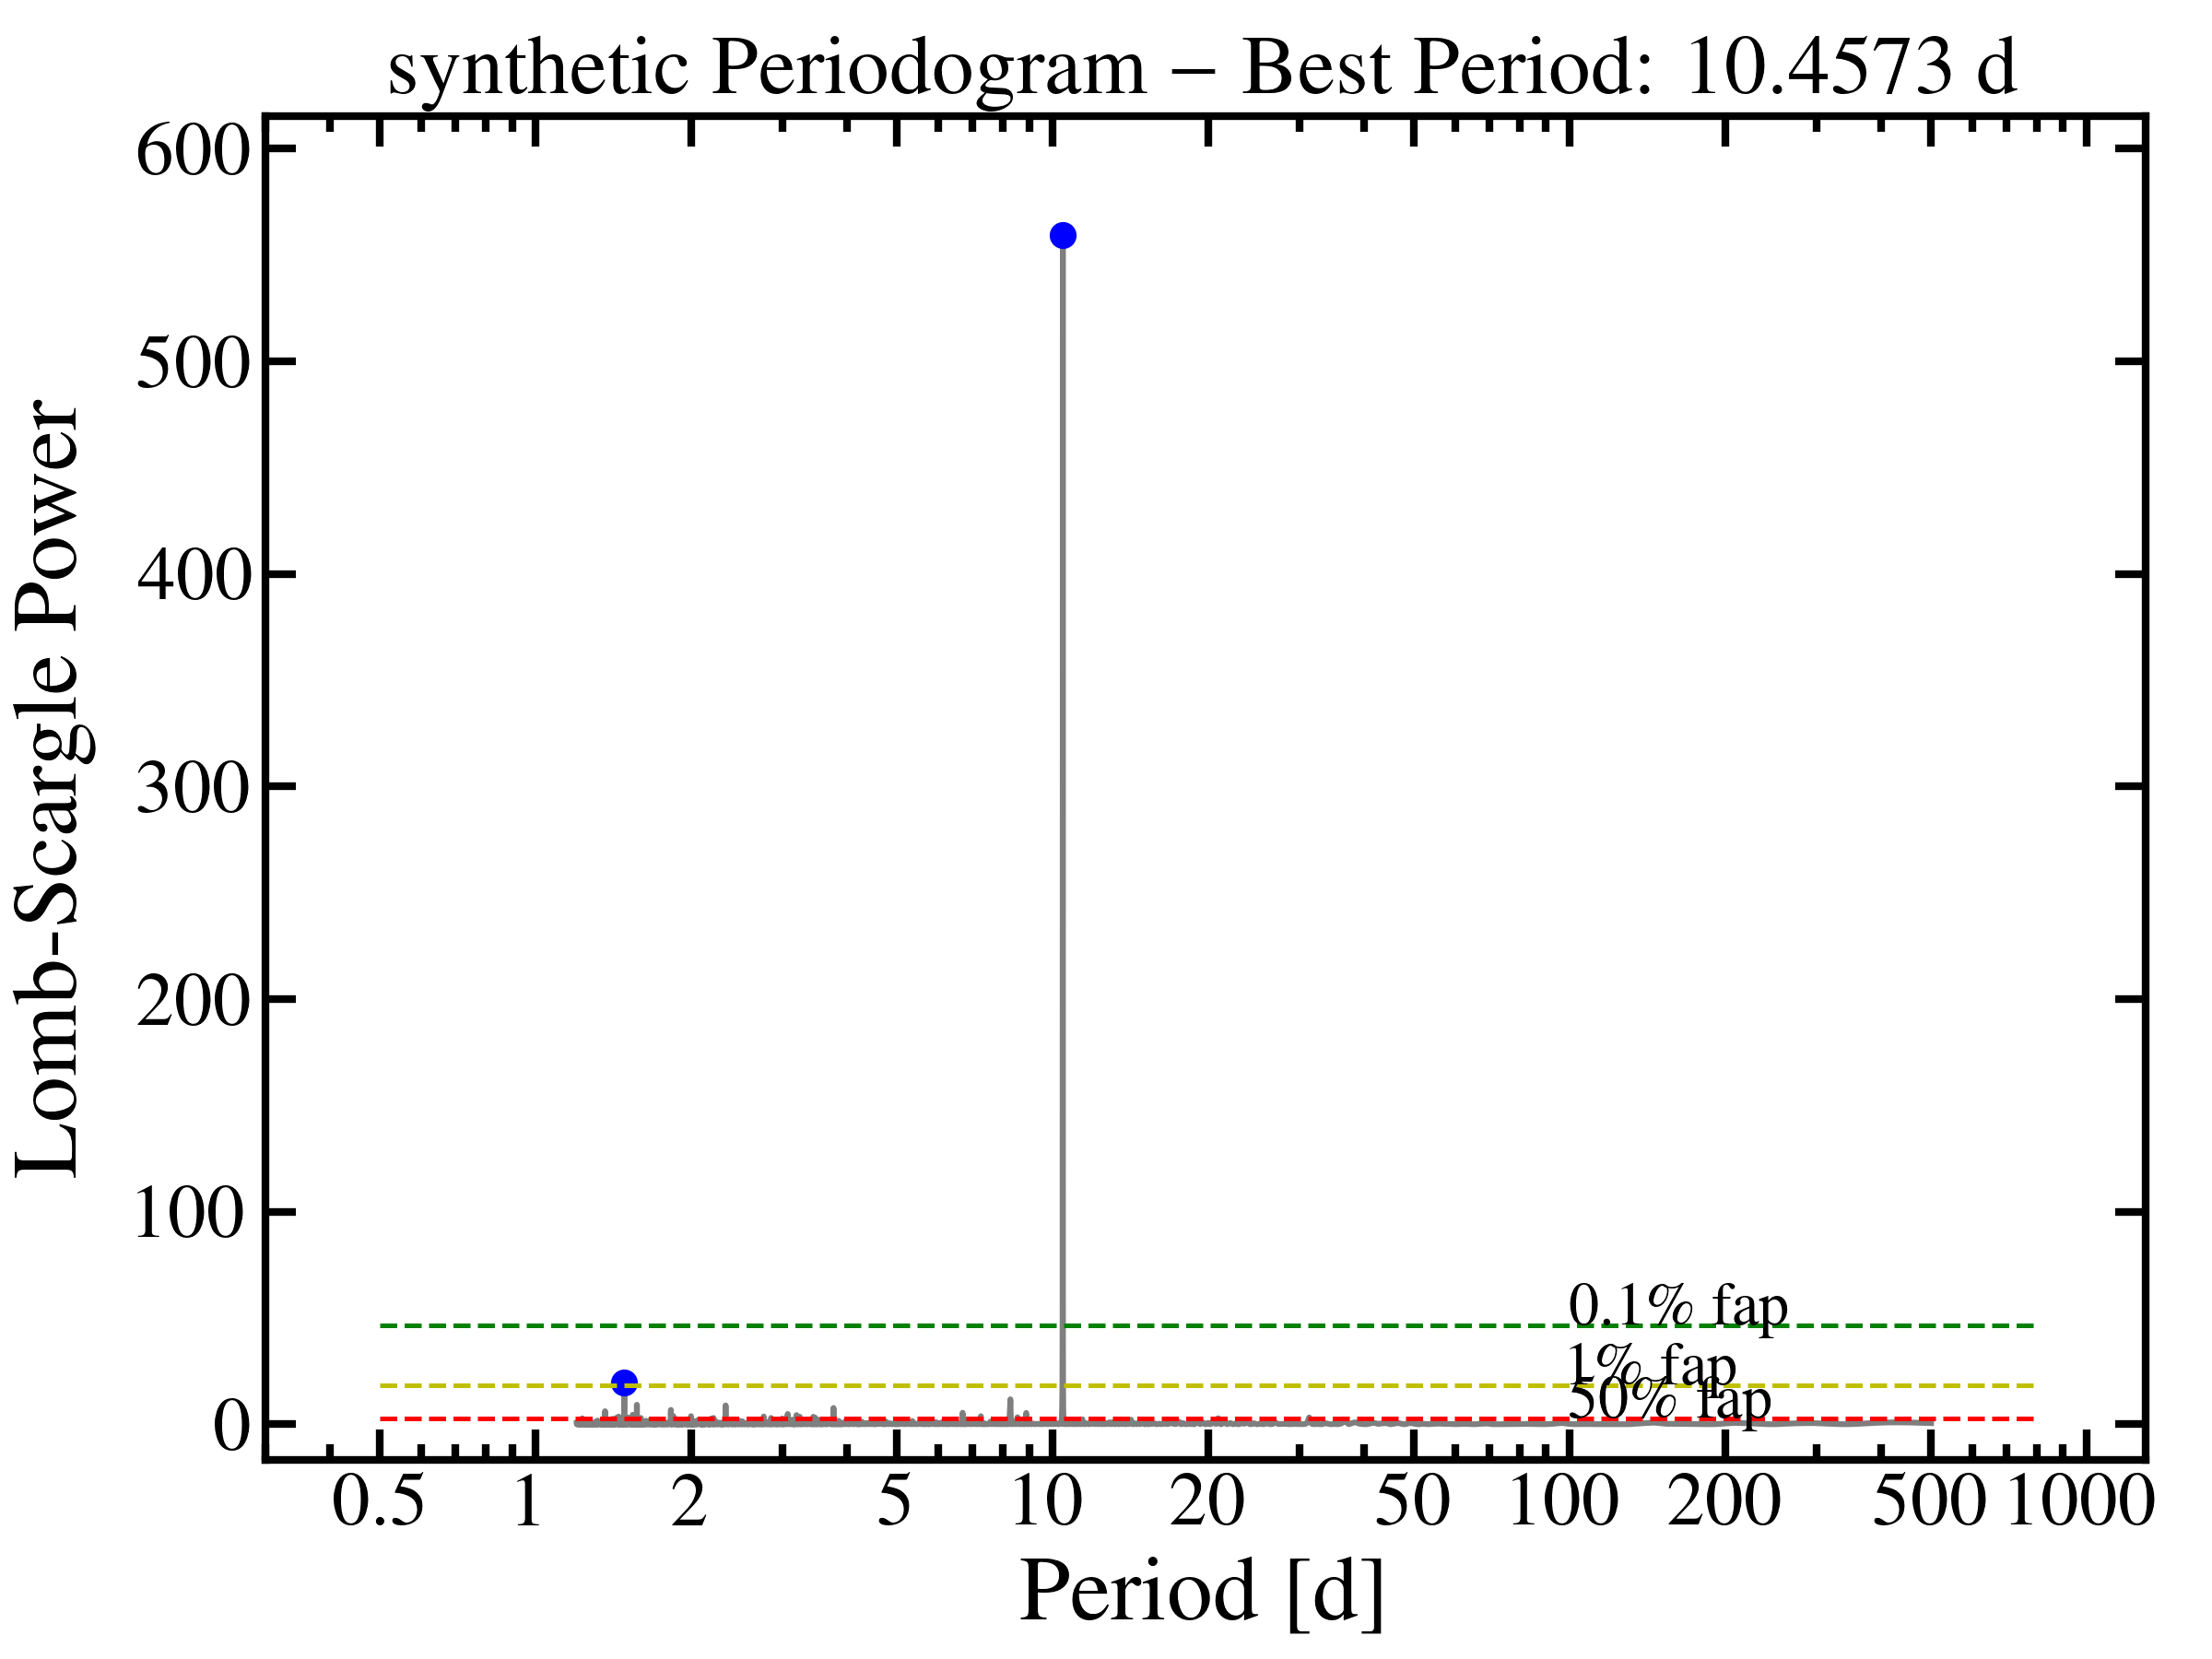

In [58]:
display(Image(
    filename='SB2_2/SB2/LS/LS_synthetic_period_primary_12_epochs.png',
    width=600  # pixels
))

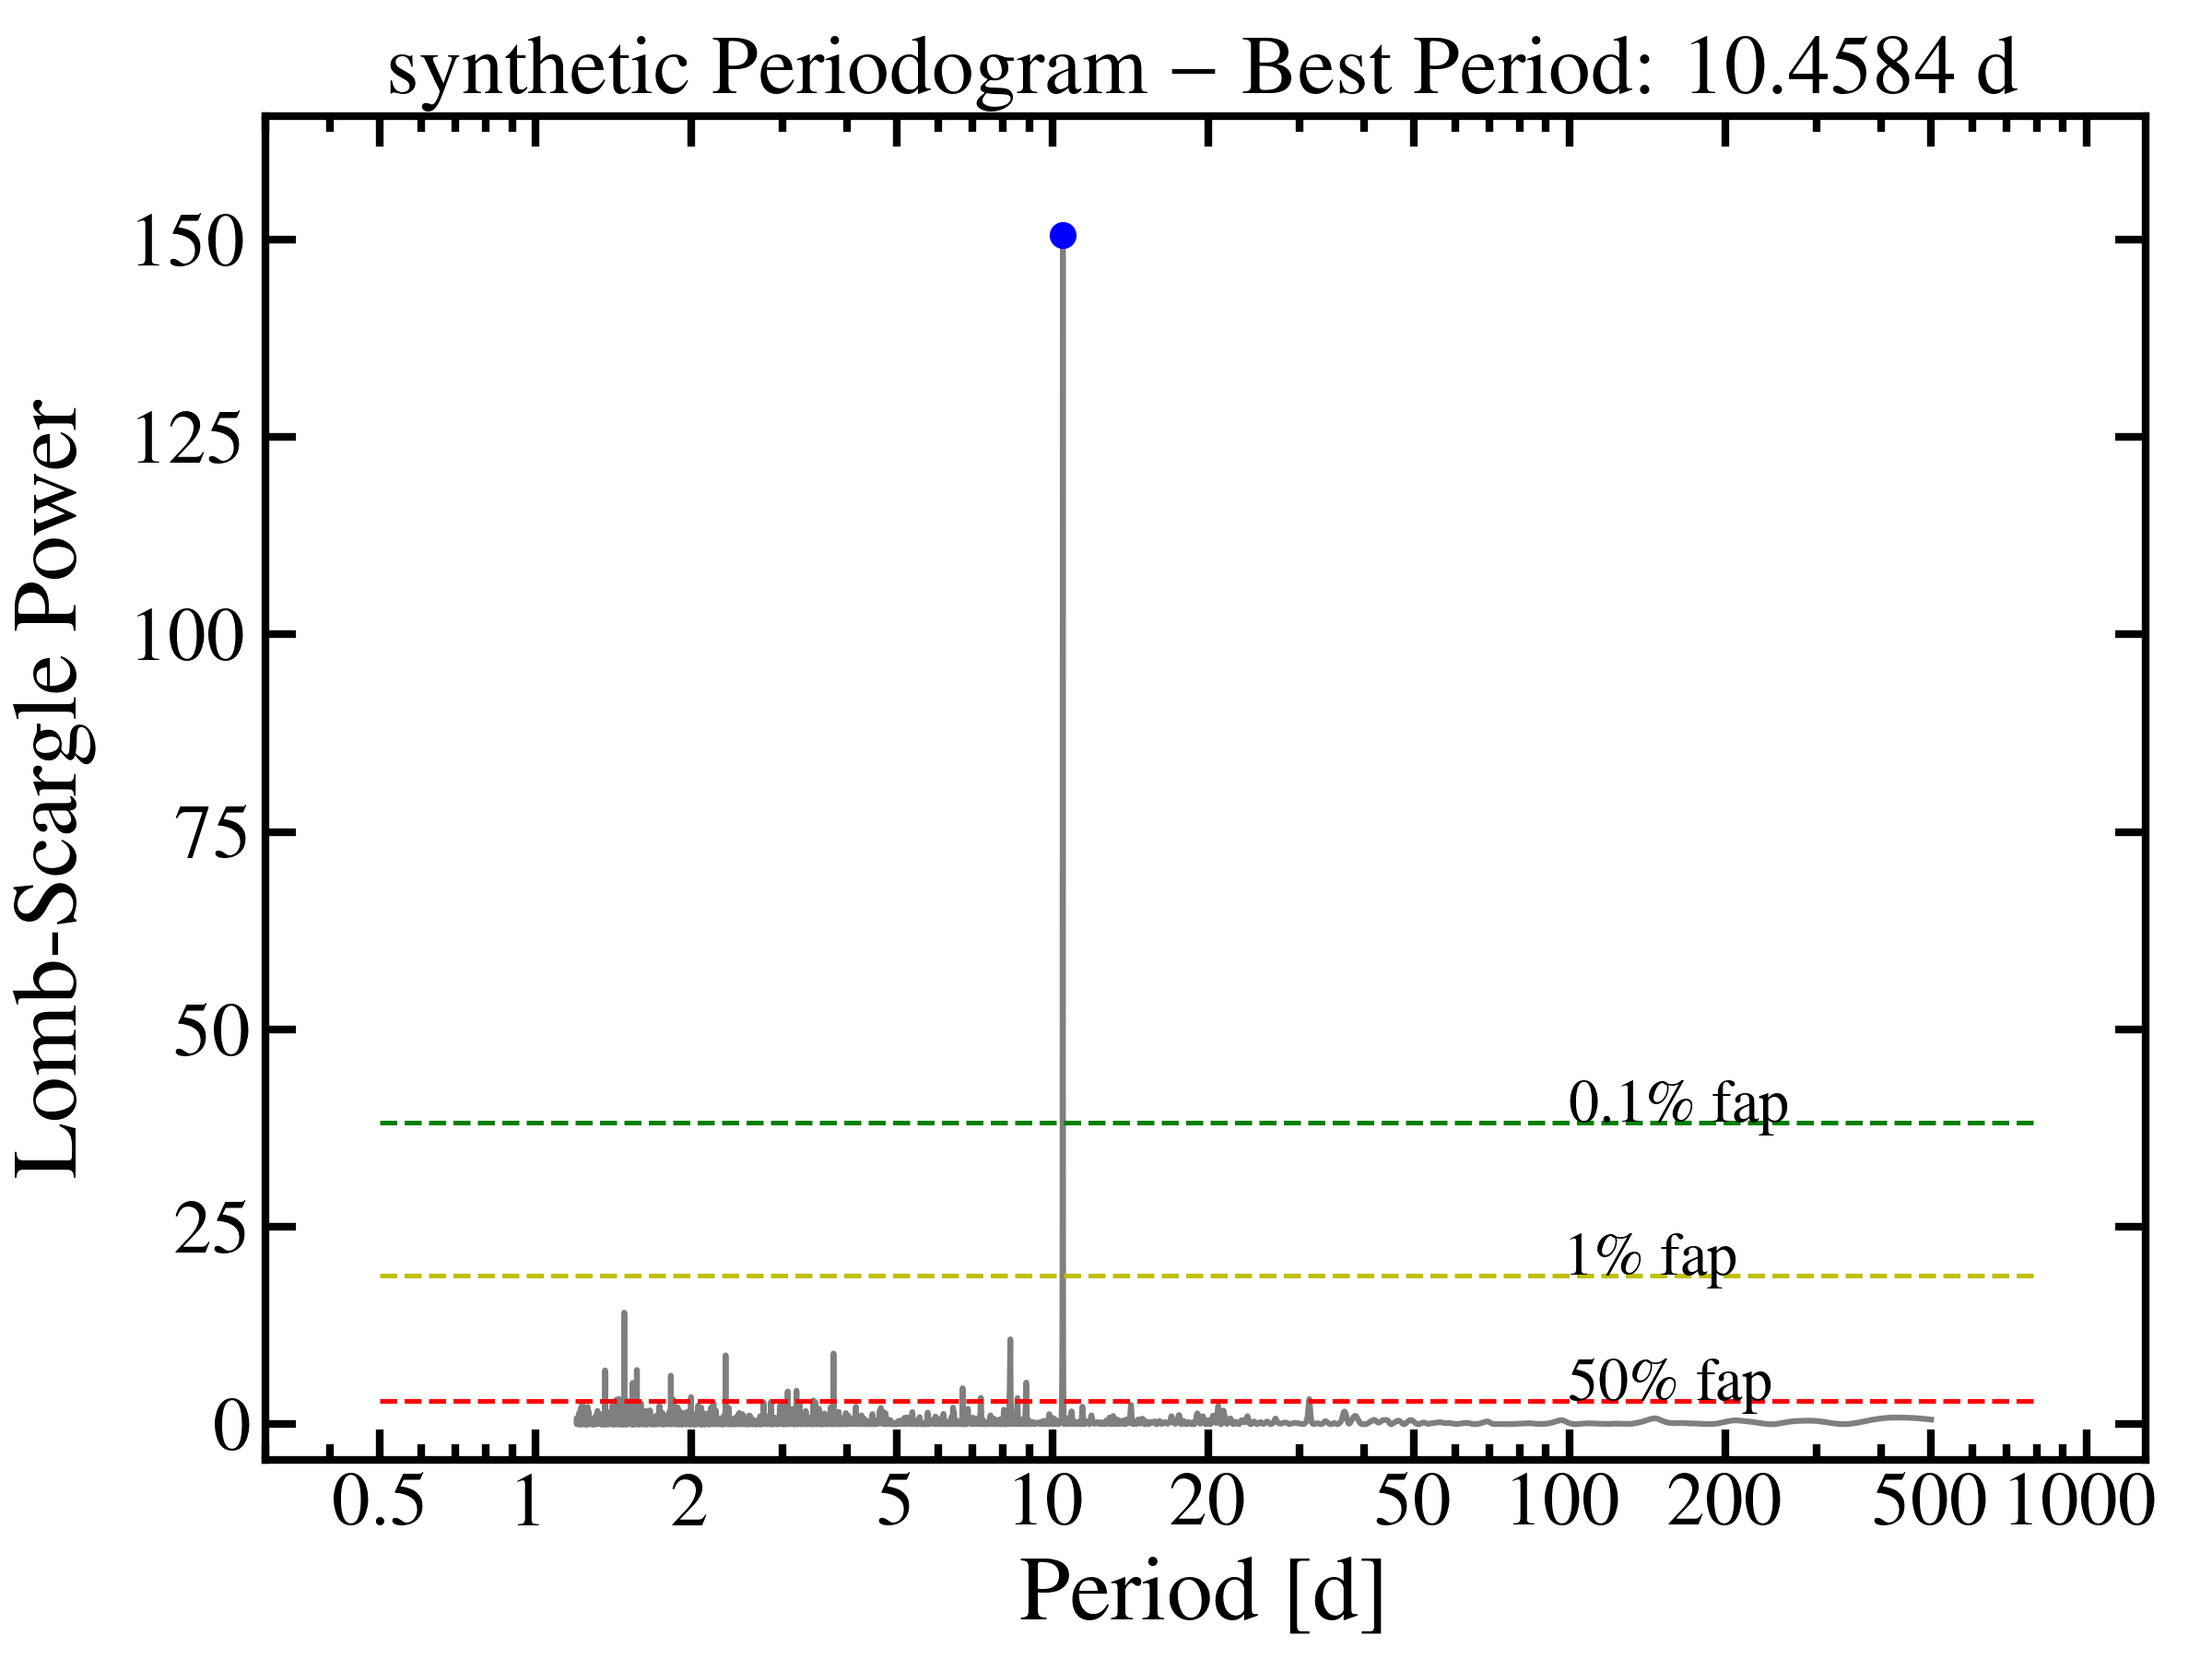

In [59]:
display(Image(
    filename='SB2_2/SB2/LS/LS_synthetic_period_secondary_12_epochs.png',
    width=600  # pixels
))

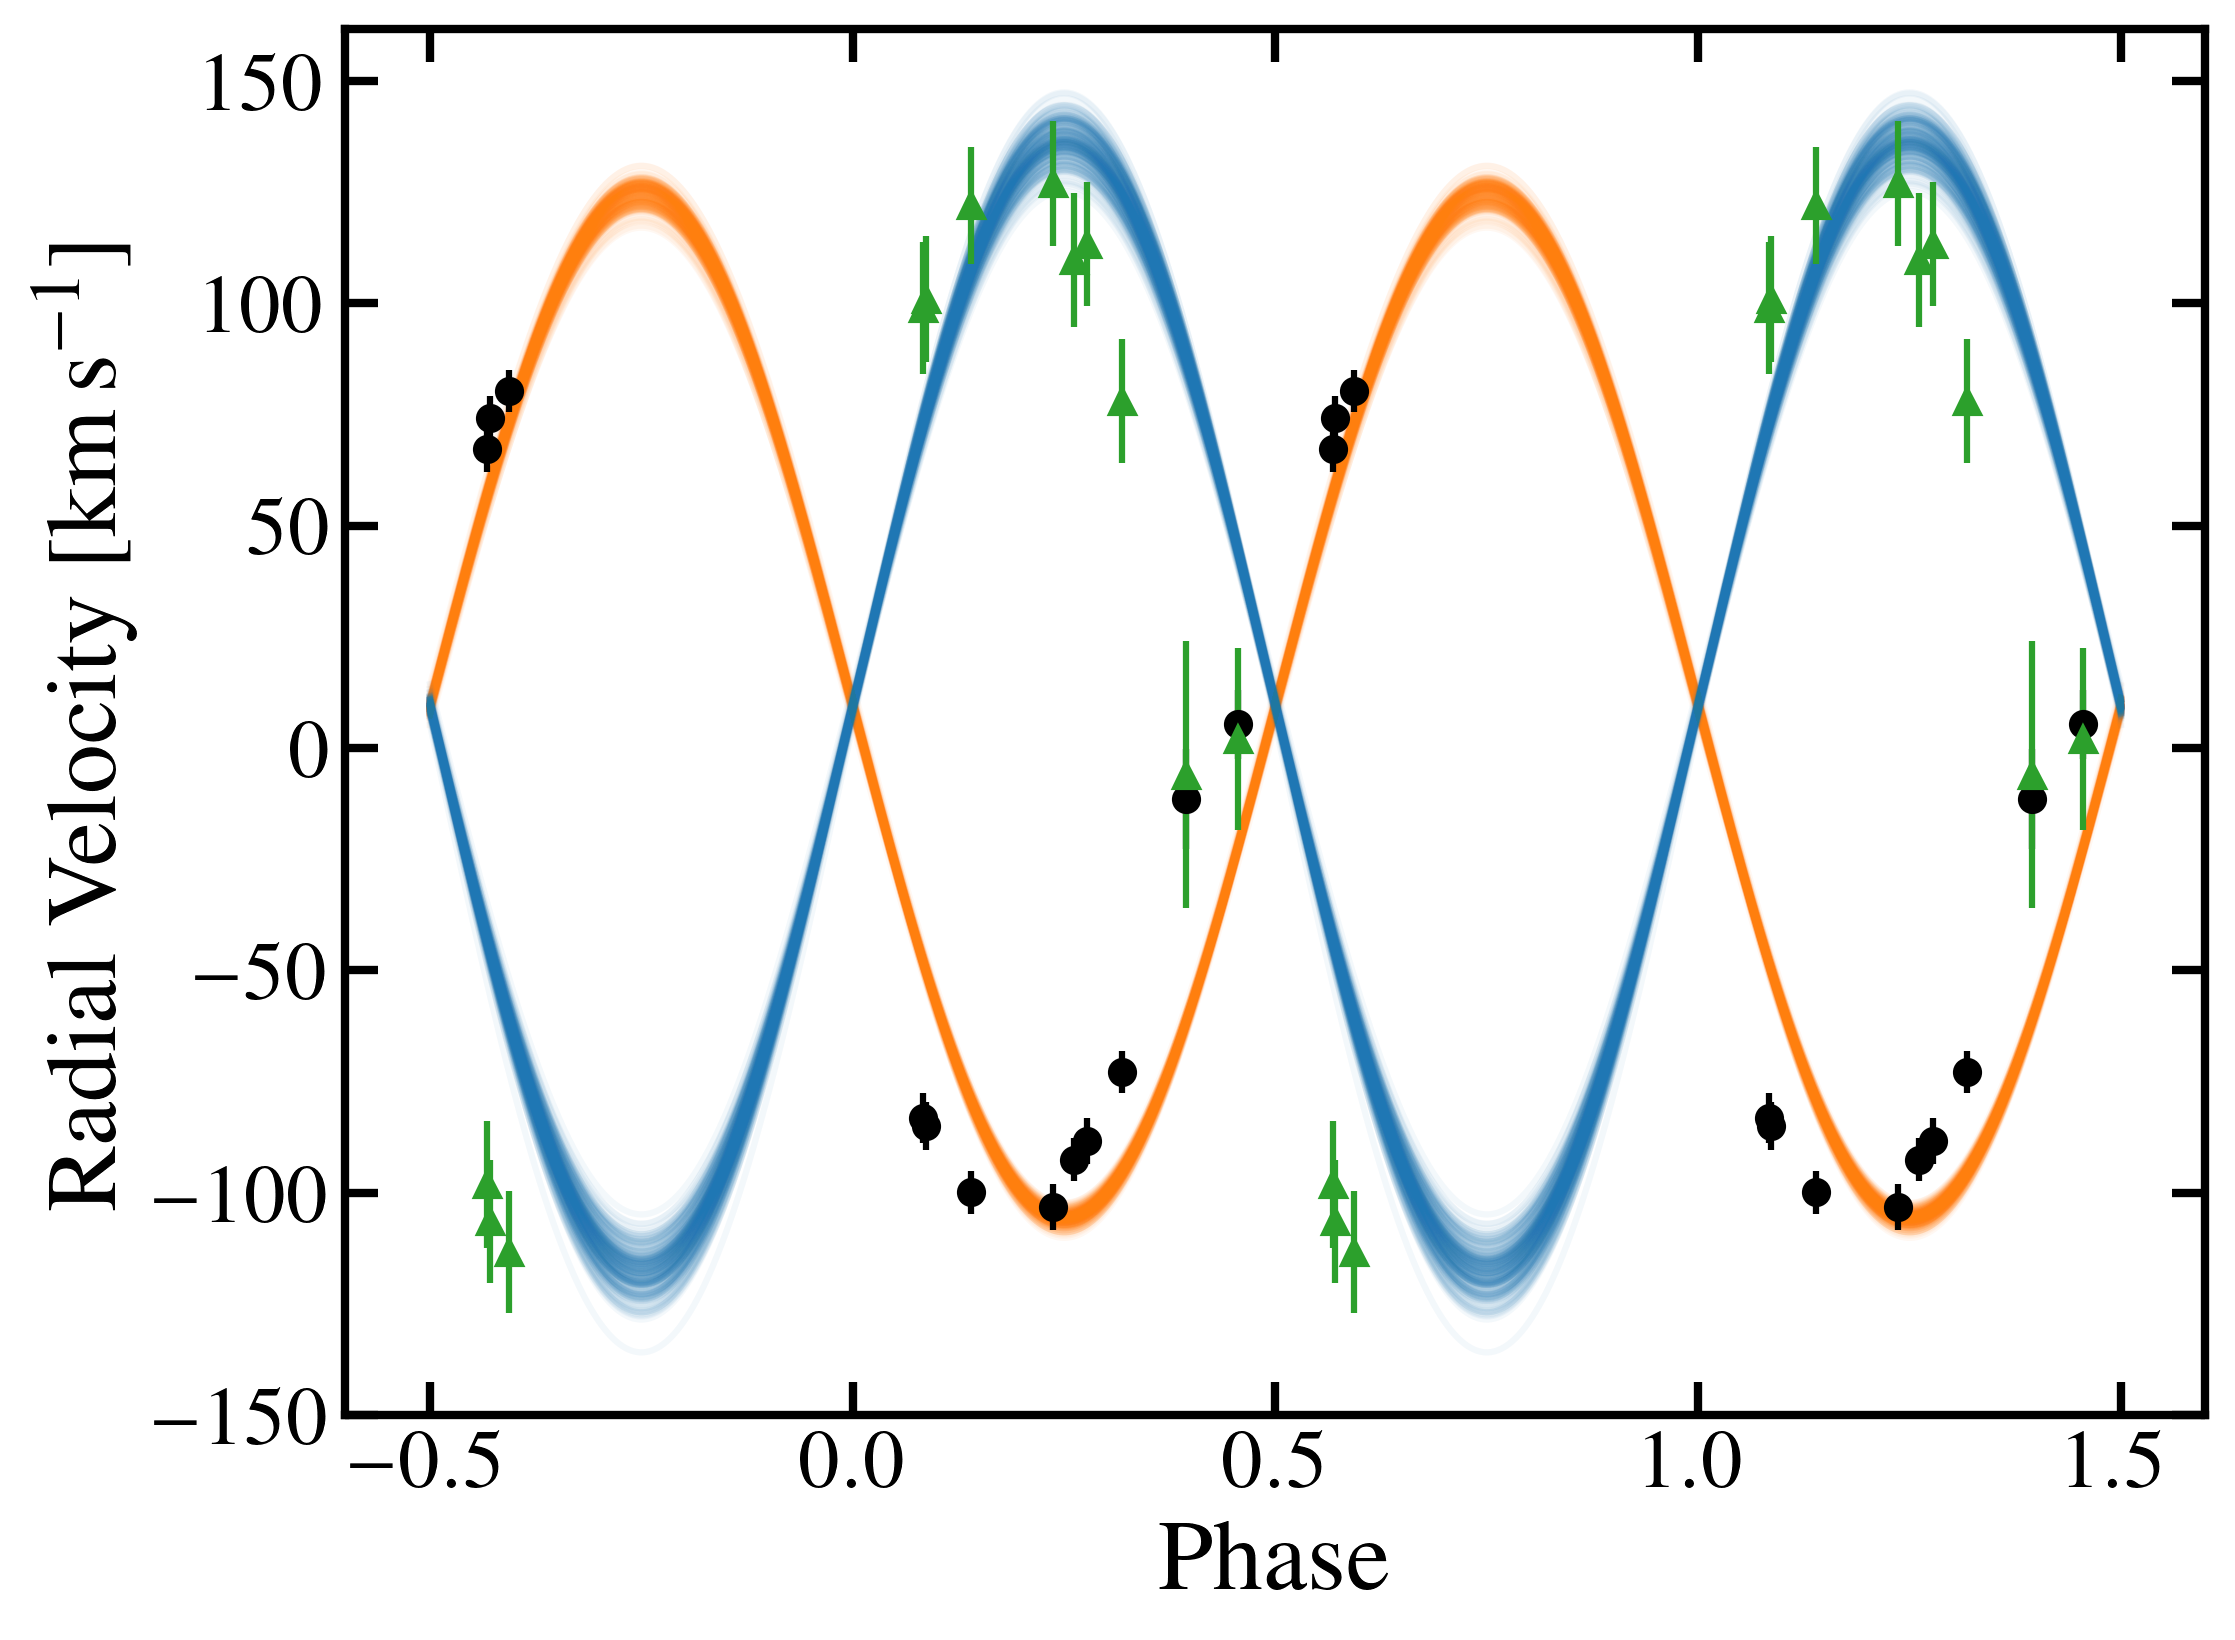

In [60]:
display(Image(
    filename='SB2_2/SB2/LS/synthetic_sinu_fit_SB2_P=10.46.png',
    width=600  # pixels
))

In [61]:
K1 = phase_results['K1'].mean()
K2 = phase_results['K2'].mean()
print('K1 (true) =', 102.259329)
print('K1 =', K1, '+/-', phase_results['K1'].std())
q = K1/K2
print('K2 (true) =', 102.259329/0.736989)
print('K2 =', K2, '+/-', phase_results['K2'].std())
print('q (true) =', 0.736989)
print('q =', q)

K1 (true) = 102.259329
K1 = 98.64917821370625 +/- 1.445177106946615
K2 (true) = 138.75285655552526
K2 = 133.28421806521442 +/- 3.9367418341562397
q (true) = 0.736989
q = 0.7401414784564992


(array([1.000e+00, 7.000e+00, 1.100e+01, 3.300e+01, 9.200e+01, 2.070e+02,
        4.240e+02, 7.690e+02, 1.218e+03, 1.518e+03, 1.754e+03, 1.724e+03,
        1.552e+03, 1.143e+03, 7.900e+02, 4.160e+02, 2.010e+02, 9.700e+01,
        3.300e+01, 1.000e+01]),
 array([116.95252459, 118.43954983, 119.92657508, 121.41360032,
        122.90062557, 124.38765081, 125.87467606, 127.3617013 ,
        128.84872655, 130.3357518 , 131.82277704, 133.30980229,
        134.79682753, 136.28385278, 137.77087802, 139.25790327,
        140.74492851, 142.23195376, 143.71897901, 145.20600425,
        146.6930295 ]),
 <BarContainer object of 20 artists>)

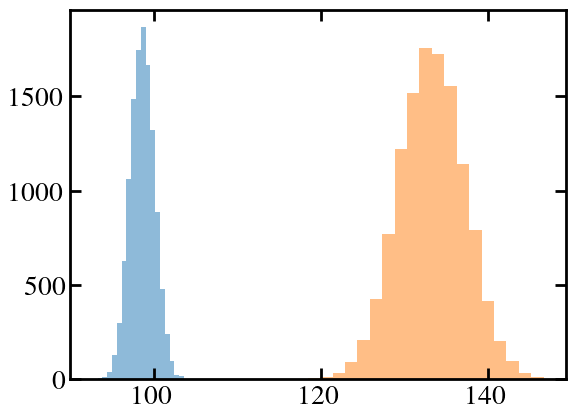

In [62]:
plt.hist(phase_results['K1'], bins=20, alpha=0.5, label='K1')
plt.hist(phase_results['K2'], bins=20, alpha=0.5, label='K2')